# FINAL PROJECT: Computational Cognitive Science

Participants:
- Ashhad Raza Quadri
- Saliq Neyaz
- Maria Alejandra Pabon Galindo

In [1]:
# Imports
import pandas as pd
from scipy.io import loadmat
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon




## 1. Data

In [2]:
COLS = ["r_cert", "r_unc", "prob", "choice", "p_cert", "condition", "rt", "odds"]
EXPECTED = ['certOutcome', 'uncOutcome', 'outcome prob.',
            'action (1=certain, 2=uncertain, 0=missing)', 'p_cert',
            'condition (1=reward,2=loss)', 'RT', 'odds']
            

### 1.1 Data loading

In [3]:
DATASET = "PD_data"

RT_LO = 0.25    # secs
FAST_THR = 0.40                # threshold for marking "rapid response"
FAST_MAX = 0.10                # >10% of rapid tests = participant flagged

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})

# Every figure reported in the write-up is written to FIGDIR by savefig_show(),
# so the notebook reproduces the report's figures without manual intervention.
FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

def savefig_show(name):
    plt.savefig(FIGDIR / f"{name}.pdf", bbox_inches="tight")
    plt.savefig(FIGDIR / f"{name}.png", dpi=200, bbox_inches="tight")
    plt.show()



def read_labels(m):
    lab = np.atleast_1d(np.squeeze(m["data_labels"]))
    return [str(np.squeeze(x)).strip() for x in lab]

def load_data(data_dir):
    files = sorted(Path(data_dir).glob("*.mat"))
    if not files:
        raise FileNotFoundError(f"No .mat files in {data_dir}")
    frames = []
    for f in files:
        m = loadmat(f, squeeze_me=True)
        
        if read_labels(m) != EXPECTED:
            raise ValueError(f"{f.name}: unexpected labels -> {read_labels(m)}")

        for run, key in [("A", "data_train"), ("B", "data_test")]:
            arr = np.atleast_2d(np.asarray(m[key], dtype=float))
            if arr.shape[1] != len(COLS):
                raise ValueError(f"{f.name}/{key}: {arr.shape[1]} cols, expected {len(COLS)}")
            d = pd.DataFrame(arr, columns=COLS)
            d.insert(0, "trial", np.arange(1, len(d) + 1))
            d.insert(0, "run", run)
            d.insert(0, "participant_id", f.stem)
            frames.append(d)
    return pd.concat(frames, ignore_index=True)

df = load_data(DATASET) 
print(df.participant_id.nunique(), "participants,", len(df), "trials")
print(df.groupby("run").size().to_dict())
df.head()


49 participants, 19600 trials
{'A': 9800, 'B': 9800}


,participant_id,run,trial,r_cert,r_unc,prob,choice,p_cert,condition,rt,odds
0,2rrjzhgj9,A,1,-1.0,-1.30,25.0,2.0,NaN,2.0,2351.9,3.000000
1,2rrjzhgj9,A,2,-20.0,-200.00,25.0,1.0,NaN,2.0,2610.8,3.000000
2,2rrjzhgj9,A,3,-50.0,-1550.00,25.0,1.0,NaN,2.0,2924.4,3.000000
3,2rrjzhgj9,A,4,-10.0,-21.11,90.0,1.0,NaN,2.0,2452.4,0.111111
4,2rrjzhgj9,A,5,-1.0,-1.01,90.0,2.0,NaN,2.0,2789.7,0.111111


### 1.2 Data cleaning

1. Drop trials with a missing choice (`choice == 0`) -- these are timeouts, with `RT == NaN`.
2. Drop trials with `RT < 250ms` (a fixed, global floor, not computed per participant) to exclude implausibly fast anticipatory/guess responses. The fastest observed response is 200 ms and the slowest 9996 ms, with no pile-up at either edge (2 trials at exactly 200 ms; 4 above 9900 ms), so there is no evidence of censoring and no upper cut-off is applied
3. Separately (see the per-participant diagnostic below), flag -- but do not drop -- participants whose proportion of fast responses or extreme choice rate looks atypical.


In [4]:
def clean(df, rt_lo=RT_LO, verbose=True):
    d, n0 = df.copy(), len(df)

    # Exclude non-responses (these are timeouts; their RT is NaN)
    d = d[d.choice.isin([1, 2])]
    n1 = len(d)

    # 2) units: ms -> s
    d["rt"] = d.rt / 1000.0

    # 3) RT limits
    fasts = int((d.rt < rt_lo).sum())
    d = d[(d.rt >= rt_lo)]
    n2 = len(d)

    # 4) derived columns
    d["p"]     = d.prob / 100.0                          # percentage -> proportion
    d["theta"] = (1 - d.p) / d.p                         # probabilities against
    d["y"]     = (d.choice == 2).astype(float)           # 1 = chose the uncertain option
    d["scale"] = (d.r_cert.abs() + d.r_unc.abs()) / 2    # numerical normalization of ΔV
    d["ratio"] = d.r_unc.abs() / d.r_cert.abs()          # ratio of magnitudes

    # verification: the odds column in the file should match our formula
    if not np.allclose(d.odds, d.theta, rtol=1e-6):
        print("WARN: column 'odds' does not match (1-p)/p; using calculated theta")
    assert (d[d.condition == 1][["r_cert", "r_unc"]] > 0).all().all(), "non-positive earnings"
    assert (d[d.condition == 2][["r_cert", "r_unc"]] < 0).all().all(), "non-negative losses"

    if verbose:
        print(f"no-response : {n0-n1:5d}  ({(n0-n1)/n0:.3%})")
        print(f"RT < {rt_lo}s   : {fasts:5d}  ({fasts/n1:.3%})")
        print(f"left       : {n2} trials, {d.participant_id.nunique()} participants")
        print("\nRT after cleaning (s):",
              d.rt.describe([.01, .5, .99]).round(2).to_dict())
        print("ratio |r_unc|/|r_cert|:", d.ratio.describe([.05, .5, .95]).round(2).to_dict())

    return d.reset_index(drop=True)

data = clean(df)

no-response :    68  (0.347%)
RT < 0.25s   :   105  (0.538%)
left       : 19427 trials, 49 participants

RT after cleaning (s): {'count': 19427.0, 'mean': 2.25, 'std': 1.36, 'min': 0.25, '1%': 0.32, '50%': 1.95, '99%': 6.98, 'max': 10.0}
ratio |r_unc|/|r_cert|: {'count': 19427.0, 'mean': 284.84, 'std': 6883.3, 'min': 0.99, '5%': 1.0, '50%': 2.23, '95%': 91.0, 'max': 626347.84}


### 1.3 Data diagnosis

In [5]:
# ---------- Per-participant diagnostic ----------
# One row per participant. Documents the sample and is used in Step 7
# to check whether the atypical/outlier participants are the ones that fit worst.

r = df[df.choice.isin([1, 2])].copy()
r["rt_s"] = r.rt / 1000
r["y"]    = (r.choice == 2).astype(float)

QC = pd.DataFrame({
    "prop_fast":   r.groupby("participant_id").rt_s.apply(lambda x: (x < FAST_THR).mean()),
    "rt_median":   r.groupby("participant_id").rt_s.median(),
    "p_uncertain": r.groupby("participant_id").y.mean(),
})
QC["extreme"] = (QC.p_uncertain < .05) | (QC.p_uncertain > .95)
QC["fast"]    = QC.prop_fast > FAST_MAX

print(f"extreme choice (>95% one option): {QC.extreme.sum()} participants")
print(f"fast RTs (>{FAST_MAX:.0%} below {FAST_THR}s): {QC.fast.sum()} participants")
print(QC[QC.extreme | QC.fast].round(3))


extreme choice (>95% one option): 0 participants
fast RTs (>10% below 0.4s): 4 participants
                prop_fast  rt_median  p_uncertain  extreme  fast
participant_id                                                  
bh348lli7           0.569      0.379        0.321    False  True
orxx7nl6z           0.218      0.656        0.382    False  True
ru26ufirj           0.119      2.054        0.424    False  True
s4xqtibhr           0.454      0.443        0.480    False  True


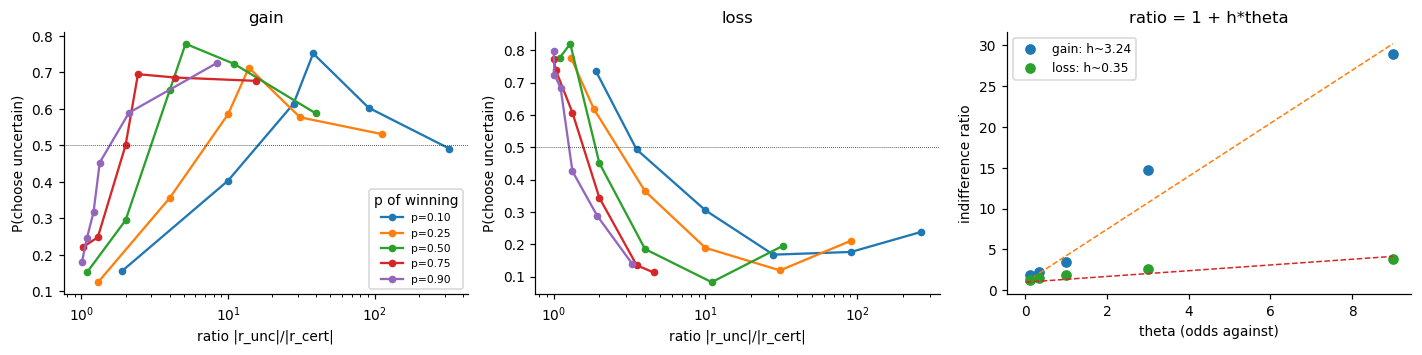

   cond     p  theta  ratio_indiff  slope
0     1  0.10  9.000        28.889  0.264
1     1  0.25  3.000        14.780  0.358
2     1  0.50  1.000         3.513  0.869
3     1  0.75  0.333         2.212  1.249
4     1  0.90  0.111         1.832  1.954
5     2  0.10  9.000         3.882 -0.837
6     2  0.25  3.000         2.668 -1.329
7     2  0.50  1.000         1.831 -2.493
8     2  0.75  0.333         1.462 -3.182
9     2  0.90  0.111         1.301 -4.312

empirical h: {1: 3.241, 2: 0.351}


In [6]:
from scipy.optimize import curve_fit

fig, ax = plt.subplots(1, 3, figsize=(13, 3.3))

# --- Panels 1-2: choice vs. magnitude ratio, by level of p ---
for i, (c, lab) in enumerate([(1, "gain"), (2, "loss")]):
    d = data[data.condition == c]
    for p_val in sorted(d.p.unique()):
        dp = d[d.p == p_val]
        b = pd.qcut(np.log(dp.ratio), 6, duplicates="drop")
        g = dp.groupby(b, observed=True).agg(x=("ratio", "median"), y=("y", "mean"))
        ax[i].plot(g.x, g.y, "o-", ms=4, label=f"p={p_val:.2f}")
    ax[i].set_xscale("log")
    ax[i].axhline(.5, color="k", lw=.5, ls=":")
    ax[i].set(xlabel="ratio |r_unc|/|r_cert|", ylabel="P(choose uncertain)", title=lab)
ax[0].legend(fontsize=7, title="p of winning")

# --- Panel 3: model-free empirical h ---
# At indifference V_unc = V_cert  ->  ratio = 1 + h*theta  (line with slope h)
rows = []
for c in [1, 2]:
    sign = 1 if c == 1 else -1          # losses: negative logistic slope
    for p_val in sorted(data.p.unique()):
        d = data[(data.condition == c) & (data.p == p_val)]
        if d.y.std() == 0:
            continue
        try:
            a, b_ = curve_fit(lambda x, a, b: 1/(1+np.exp(-(a+b*x))),
                              np.log(d.ratio.values), d.y.values,
                              p0=[0, sign], maxfev=20000)[0]
            if np.sign(b_) == sign and abs(b_) > 1e-3:
                rows.append(dict(cond=c, p=p_val, theta=(1-p_val)/p_val,
                                  ratio_indiff=np.exp(-a/b_), slope=b_))
        except Exception:
            pass
IND = pd.DataFrame(rows)

H_EMP = {}
for c, lab in [(1, "gain"), (2, "loss")]:
    d = IND[IND.cond == c]
    if len(d) < 2:
        print(f"WARNING: only {len(d)} indifference points for {lab}")
        continue
    h = float(np.sum(d.theta * (d.ratio_indiff - 1)) / np.sum(d.theta**2))
    H_EMP[c] = h
    ax[2].plot(d.theta, d.ratio_indiff, "o", label=f"{lab}: h~{h:.2f}")
    tt = np.linspace(0, d.theta.max(), 50)
    ax[2].plot(tt, 1 + h*tt, "--", lw=1)
ax[2].set(xlabel="theta (odds against)", ylabel="indifference ratio",
          title="ratio = 1 + h*theta")
ax[2].legend(fontsize=8)

plt.tight_layout(); savefig_show("fig1_data")
print(IND.round(3))
print("\nempirical h:", {k: round(v, 3) for k, v in H_EMP.items()})


In [7]:
# ---------- Preprocessing summary (for the methods section) ----------
summary = {
    "participants":           data.participant_id.nunique(),
    "raw_trials":              len(df),
    "final_trials":            len(data),
    "excl_no_response":        int((~df.choice.isin([1, 2])).sum()),
    "excl_fast_rt":            len(df) - int((~df.choice.isin([1, 2])).sum()) - len(data),
    "h_emp_gain":              round(H_EMP.get(1, np.nan), 3),
    "h_emp_loss":              round(H_EMP.get(2, np.nan), 3),
    "flagged_fast_rt":         int(QC.fast.sum()),
    "flagged_extreme_choice":  int(QC.extreme.sum()),
}
print(pd.Series(summary))

print("\ntrials per participant x run x condition cell:")
print(data.groupby(["run", "condition"]).size().unstack())

# ---------- descriptives per condition (for the methods section) ----------
desc = data.groupby("condition").agg(
    trials=("y", "size"), p_uncertain=("y", "mean"),
    rt_median=("rt", "median"), rt_q25=("rt", lambda x: x.quantile(.25)),
    rt_q75=("rt", lambda x: x.quantile(.75)))
desc.index = ["reward", "loss"]
print("\nper condition:")
print(desc.round(3))
print(f"\nbetween-participant SD of P(uncertain): "
      f"{data.groupby(['participant_id','condition']).y.mean().groupby('condition').std().round(3).to_dict()}")
print(f"participant median RT ranges from {data.groupby('participant_id').rt.median().min():.2f}s "
      f"to {data.groupby('participant_id').rt.median().max():.2f}s")
print(f"RT skew: {data.rt.skew():.2f} raw, {np.log(data.rt).skew():.2f} on the log scale "
      f"-- the log transform is what makes a symmetric noise model appropriate")


participants                 49.000
raw_trials                19600.000
final_trials              19427.000
excl_no_response             68.000
excl_fast_rt                105.000
h_emp_gain                    3.241
h_emp_loss                    0.351
flagged_fast_rt               4.000
flagged_extreme_choice        0.000
dtype: float64

trials per participant x run x condition cell:
condition   1.0   2.0
run                  
A          4877  4850
B          4851  4849

per condition:
        trials  p_uncertain  rt_median  rt_q25  rt_q75
reward    9728        0.464      1.811   1.288   2.597
loss      9699        0.432      2.088   1.423   3.028

between-participant SD of P(uncertain): {1.0: 0.144, 2.0: 0.097}
participant median RT ranges from 0.40s to 3.50s
RT skew: 1.55 raw, -0.51 on the log scale -- the log transform is what makes a symmetric noise model appropriate


### 1.4 Are run A and run B comparable?


In [8]:
# ---------- Run A vs run B: are the two sessions comparable? ----------
# Reliability and out-of-sample prediction both treat run B as a rerun of run A.
# It is not exactly one, and the differences shape how the later results read.
rows = []
for pid, g in data.groupby("participant_id"):
    a, b = g[g.run == "A"], g[g.run == "B"]
    lo, hi = np.log(a.ratio).min(), np.log(a.ratio).max()
    rows.append(dict(pid=pid, p_unc_A=a.y.mean(), p_unc_B=b.y.mean(),
                     rt_A=a.rt.median(), rt_B=b.rt.median(),
                     lr_A=np.log(a.ratio).mean(), lr_B=np.log(b.ratio).mean(),
                     outside=((np.log(b.ratio) > hi) | (np.log(b.ratio) < lo)).mean()))
AB = pd.DataFrame(rows).set_index("pid")

print("=== design ===")
print(f"mean log magnitude ratio:  A={AB.lr_A.mean():.2f}   B={AB.lr_B.mean():.2f}")
print(f"run B trials outside the participant's own run A ratio range: "
      f"mean {AB.outside.mean():.1%}, median {AB.outside.median():.1%}, max {AB.outside.max():.1%}")

print("\n=== behaviour ===")
print(f"P(uncertain):  A={AB.p_unc_A.mean():.3f}  B={AB.p_unc_B.mean():.3f}  "
      f"p={wilcoxon(AB.p_unc_A, AB.p_unc_B)[1]:.2g}")
print(f"median RT:     A={AB.rt_A.median():.2f}s  B={AB.rt_B.median():.2f}s  "
      f"faster in B for {(AB.rt_B < AB.rt_A).sum()}/{len(AB)}  "
      f"p={wilcoxon(AB.rt_A, AB.rt_B)[1]:.1g}")

# Does the choice shift survive conditioning on the offer actually presented?
mt = data.copy()
mt["rb"] = pd.qcut(np.log(mt.ratio), 8, duplicates="drop")
cell = (mt.groupby(["participant_id", "run", "condition", "p", "rb"], observed=True)
          .y.mean().reset_index()
          .pivot_table(index=["participant_id", "condition", "p", "rb"],
                       columns="run", values="y", observed=True).dropna())
print(f"\ndesign-matched (participant x condition x p x ratio octile, {len(cell)} cells): "
      f"A={cell.A.mean():.3f}  B={cell.B.mean():.3f}  "
      f"shift={(cell.B - cell.A).mean():+.3f}  p={wilcoxon(cell.A, cell.B)[1]:.2g}")

print("\nRun B is therefore neither a replication of the run A design nor a fresh draw from")
print("the same behaviour: the offers move to larger ratios, responses speed up markedly,")
print("and a small shift towards the uncertain option survives conditioning on the offer.")
print("Section 3 fixes tau and a from run A, so the speed-up is absorbed nowhere: it is the")
print("main reason the out-of-sample RT likelihood sits well below the in-sample one.")


=== design ===
mean log magnitude ratio:  A=1.32   B=1.73
run B trials outside the participant's own run A ratio range: mean 23.0%, median 17.0%, max 74.5%

=== behaviour ===
P(uncertain):  A=0.394  B=0.503  p=0.00096
median RT:     A=2.19s  B=1.77s  faster in B for 45/49  p=2e-12

design-matched (participant x condition x p x ratio octile, 1440 cells): A=0.431  B=0.469  shift=+0.038  p=0.0015

Run B is therefore neither a replication of the run A design nor a fresh draw from
the same behaviour: the offers move to larger ratios, responses speed up markedly,
and a small shift towards the uncertain option survives conditioning on the offer.
Section 3 fixes tau and a from run A, so the speed-up is absorbed nowhere: it is the
main reason the out-of-sample RT likelihood sits well below the in-sample one.


## 2. Valuation model & choice rule

**Valuation model — Rachlin hyperboloid-in-odds probability discounting** (Rachlin,
Raineri & Cross, 1991). The certain option carries no risk and needs no discounting:
$$V_{cert} = r_{cert}$$
The uncertain option is discounted by the odds against its probabilistic outcome,
$\Theta = (1-p)/p$:
$$V_{unc}(h) = \frac{r_{unc}}{1 + h\,\Theta}, \qquad h \ge 0$$

The hyperbolic form is supported by our own data, not assumed: at indifference the equation rearranges to $r_{unc}/r_{cert} = 1 + h\theta$, so indifference ratios should be **linear in θ**. The non-parametric estimates in Section 1 fall close to that line (h ≈ 3.24 gains, h ≈ 0.35 losses) and serve as a validation target for the fitted parameters.

- Two rates per participant: (h_gain, h_loss). The design is fully crossed (100 trials per
condition per run), and the two model-free rates differ by nearly an order of magnitude, so a
single rate would fit neither domain.
- Sign handling: Loss magnitudes are stored as negative (verified with the data). No sign correction is applied, the same equation then produces both risk attitudes: for gains V_unc shrinks toward 0 and so is *worse* than the sure gain (risk aversion); for losses it shrinks toward 0 and so is *better* than the sure loss (risk seeking). The reflection effect emerges with no extra parameter.
- Scaling: $\Delta V = (V_{unc} − V_{cert}) / [(|r_{cert}| + |r_{unc}|)/2]$. Purely numerical, magnitudes span five orders of magnitude, so without normalisation no single β could serve both small and large trials. The cost is that absolute magnitude effects cannot be expressed through this predictor.


**Choice rule (logistic on $\Delta V$):**

$$P(\text{uncertain}) = \sigma(\beta\,\Delta V + \beta_0)$$

$\beta$ is choice sensitivity (large $\beta$ = choices follow value deterministically); $\beta_0$ absorbs a value-independent bias. **Consistent with Section 1:** the model-free choice curves there (binned by magnitude ratio, separately by θ) already show the qualitative pattern this valuation model predicts — monotonic in the ratio, with the reward and loss conditions moving in opposite directions around the point of indifference.

**Parameterisation and likelihood**
Four parameters per participant, fitted unconstrained: `log_h_gain`, `log_h_loss`, `log_beta` (log scale keeps rates positive without bounded optimisation and improves conditioning) and `beta0` (unconstrained; bias may point either way).

$$\mathcal{L}_{choice} = \sum_t \big[ y_t \log P_t + (1-y_t)\log(1-P_t) \big]$$

This term is identical in every model, including the choice-only baseline. The RT models add a second term; the baseline omits it. The two likelihoods describe different data and are not directly comparable.

**Limitations**
* One β across conditions, though choices tracked value more sharply for losses.
* Normalising ΔV removes magnitude effects.
* h and β assumed constant within a run (no learning, fatigue, or drift).


**The RT distribution (held fixed): Shifted log-normal**

The brief requires that the noise distribution be identical across all RT models. If it varied, the comparison would partly measure distributional shape rather than isolating the value→RT mapping, which is the object of interest.

$$RT = \tau + \exp(\mu + \sigma\varepsilon), \qquad \varepsilon \sim \mathcal{N}(0,1)$$

**Log-density.** For rt > τ:

$$\log f(rt) = -\log(rt-\tau) - \log\sigma - \tfrac{1}{2}\log 2\pi
- \tfrac{1}{2}\left[\frac{\log(rt-\tau) - \mu}{\sigma}\right]^2$$

### Parameters

| Fitted | Recovered as | Role |
|---|---|---|
| `a`, `b` | — | Define μ; this is the only part that differs across models. |
| `log_sigma` | σ = exp(·) | RT variability on the log scale; must be positive. |
| `tau_raw` | τ = logistic(τ_raw)·0.99·min(RT) | Non-decision time. |


### 2.1 The RT models

All models share the valuation model, the choice rule, and the shifted log-normal above. They
differ only in how ΔV enters the location parameter μ.

### M1 — Linear conflict

$$\mu = a - b\,|\Delta V|$$

**Hypothesis.** Response time is driven by the *distance between the options in value space*.
The further apart they are, the faster the comparison resolves; when ΔV ≈ 0 the comparison
stalls and the response is delayed.

**Motivation.** In an evidence-accumulation (diffusion) process the drift rate is proportional
to the value difference, and mean decision time decreases approximately linearly in drift for
small drift rates. M1 is that first-order approximation.

### M2 — Decision uncertainty

$$\mu = a - b\,\big|2P(\text{uncertain}) - 1\big|$$

**Hypothesis.** What slows responding is not the objective value distance but *subjective
indecision*. The predictor measures how far the choice probability sits from 50/50: it is 0
under complete indecision and 1 under complete certainty.

**How it differs psychologically from M1.** The difference is **saturation**. Under M1,
each additional unit of ΔV always speeds responding by the same amount. Under M2, once the
participant is already nearly certain (P ≈ 0.95), further value advantage buys no additional
speed — the predictor has reached ceiling. M1 says RT tracks value; M2 says RT tracks
confidence.

### M3 — Quadratic conflict

$$\mu = a - b\,(\Delta V)^2$$

**Hypothesis.** Slowing is *concentrated at indifference*. Only near-ties are genuinely costly:
once one option holds any appreciable advantage the deliberation cost falls away quickly, and
further advantage beyond that buys progressively more speed rather than less.

**How it differs psychologically from M1 and M2.** All three are decreasing in |ΔV|, but the
curvature differs, and curvature is the psychological claim. M1 is linear: every unit of value
advantage is worth the same amount of time. M3 is convex in the predictor, so the marginal
speed-up *grows* with |ΔV| — the model asserts that difficulty is a sharply peaked function of
value distance, negligible except in a narrow band around indifference. M2 goes the opposite
way, with the marginal speed-up *shrinking* to zero at high certainty. The three therefore
bracket the plausible shapes: accelerating (M3), constant (M1), and decelerating (M2) returns
to value advantage.


### Summary of the distinction

| | Predictor | What slows the participant | Marginal effect as \|ΔV\| grows |
|---|---|---|---|
| **M1** | \|ΔV\| | Value distance | Constant |
| **M2** | \|2P−1\| | Subjective indecision | Shrinks (saturates) |
| **M3** | ΔV² | Proximity to indifference | Grows (accelerates) |

In [9]:
from scipy.special import expit

# ==================== valuation & choice (FIXED) ====================
CHOICE_PARS = ["log_h_gain", "log_h_loss", "log_beta", "beta0"]

def compute_dv(pars, d):
    """Normalized value difference. Magnitudes are already signed: no sign correction applied."""
    h     = np.where(d.condition.values == 2,
                     np.exp(pars["log_h_loss"]), np.exp(pars["log_h_gain"]))
    V_unc = d.r_unc.values / (1.0 + h * d.theta.values)
    return (V_unc - d.r_cert.values) / d.scale.values

def choice_prob(pars, dv):
    z = np.clip(np.exp(pars["log_beta"]) * dv + pars["beta0"], -500, 500)
    return np.clip(expit(z), 1e-12, 1 - 1e-12)

def ll_choice(pars, d, dv=None, pu=None):
    """Choice log-likelihood, per trial (Bernoulli)."""
    dv = compute_dv(pars, d) if dv is None else dv
    pu = choice_prob(pars, dv) if pu is None else pu
    y  = d.y.values
    return y * np.log(pu) + (1 - y) * np.log(1 - pu)

# ==================== RT distribution (FIXED) ====================
RT_PARS  = ["a", "b", "log_sigma", "tau_raw"]
LL_FLOOR = -20.0     # finite floor for rt <= tau

def get_tau(pars, rt_min):
    """0 < tau < min(RT), guaranteed by the sigmoid transform."""
    return expit(pars["tau_raw"]) * 0.99 * rt_min

def ll_rt(pars, model, d, dv, pu, rt_min, return_viol=False):
    """Shifted log-normal, IDENTICAL across all models: only mu changes."""
    tau   = get_tau(pars, rt_min)
    sigma = np.exp(pars["log_sigma"])
    mu    = rt_location(pars, model, dv, pu)
    resid = d.rt.values - tau
    ok    = resid > 1e-6
    rr    = np.where(ok, resid, 1.0)
    z     = (np.log(rr) - mu) / sigma
    ll    = -np.log(rr) - np.log(sigma) - 0.5*np.log(2*np.pi) - 0.5*z**2
    out   = np.where(ok, ll, LL_FLOOR)
    return (out, int((~ok).sum())) if return_viol else out

# ==================== RT models ====================
RT_MODELS = ["M1_abs", "M2_unc", "M3_sq"]

def rt_location(pars, model, dv, pu):
    a, b = pars["a"], pars["b"]
    if model == "M1_abs":
        return a - b * np.abs(dv)              # value distance
    if model == "M2_unc":
        return a - b * np.abs(2 * pu - 1)      # decision uncertainty
    if model == "M3_sq":
        return a - b * dv**2                   # proximity to indifference
    raise ValueError(f"unknown model: {model}")

# ==================== joint likelihood ====================
def log_lik(pars, d, model=None, rt_min=None, use_rt=True):
    """model=None or use_rt=False -> choice-only baseline."""
    dv  = compute_dv(pars, d)
    pu  = choice_prob(pars, dv)
    llc = ll_choice(pars, d, dv, pu)
    if not use_rt or model is None:
        return dict(total=llc.sum(), choice=llc.sum(), rt=np.nan)
    llr = ll_rt(pars, model, d, dv, pu, rt_min)
    return dict(total=llc.sum() + llr.sum(), choice=llc.sum(), rt=llr.sum())

def param_names(model, use_rt=True):
    return CHOICE_PARS + (RT_PARS if (use_rt and model) else [])


## 3. Infer (run A)



### Estimator: per-participant MAP

Parameters are estimated **separately for each participant** by maximum a posteriori,
using run A only. Run B is never touched at this stage.

### Likelihood

For participant *i*, trial *t*, with $y_t = 1$ if the uncertain option was chosen:

$$\mathcal{L}_i = \underbrace{\sum_t \big[y_t\log P_t + (1-y_t)\log(1-P_t)\big]}_{\text{choice}}
\; + \; \underbrace{\sum_t \log f(rt_t \mid \mu_t, \sigma, \tau)}_{\text{RT (omitted in the baseline)}}$$

with $P_t = \sigma(\beta\Delta V_t + \beta_0)$ and $f$ the shifted log-normal density of
Section 2. The **choice-only baseline** uses the identical first term with the second deleted:
it is the same model fitted to one modality, not a different model.

### Priors

Weakly informative Gaussian priors on the transformed (fitted) scale:

| Parameter | Prior | Rationale |
|---|---|---|
| `log_h_gain`, `log_h_loss` | N(0, 2²) | Centred at h = 1 (no strong stance), 95% mass over h ∈ [0.02, 55] — far wider than the model-free estimates of 3.24 and 0.35, so the data dominate. |
| `log_beta` | N(1, 1.5²) | Covers β ∈ [0.14, 52]. Rules out only numerically degenerate values. |
| `beta0` | N(0, 2²) | No stance on the direction of bias. |
| `a` | N(0.5, 1²) | Centred near log(median RT − τ) ≈ 0.6. |
| `b` | N(0, 1²) | **Centred at zero and symmetric**: the prior takes no position on whether difficulty slows or speeds responding, so a positive b is not assumed. |
| `log_sigma` | N(−0.5, 0.5²) | Matches the observed spread of log RT. |
| `tau_raw` | N(0, 1.5²) | Nearly flat over the admissible interval (0, min RT). |



In [10]:
from scipy.optimize import minimize
import hashlib, time

# Gaussian priors on the fitted scale: name -> (mean, sd)
PRIORS = {
    "log_h_gain": (0.0,  2.0),  "log_h_loss": (0.0,  2.0),
    "log_beta":   (1.0,  1.5),  "beta0":      (0.0,  2.0),
    "a":          (0.5,  1.0),  "b":          (0.0,  1.0),
    "log_sigma":  (-0.5, 0.5),  "tau_raw":    (0.0,  1.5),
}
# M3's predictor (ΔV²) lives on a smaller scale (median 0.08 vs 0.28 for |ΔV|), so an
# equivalent effect on mu needs a larger b. Widening its prior keeps the regularisation
# comparable in terms of the *effect*, not the raw coefficient — otherwise M3 would be
# penalised more heavily than M1/M2 and the model comparison would be unfair.
PRIOR_B = {"M1_abs": (0.0, 1.0), "M2_unc": (0.0, 1.0), "M3_sq": (0.0, 3.0)}

BOUNDS = {
    "log_h_gain": (-8, 6),  "log_h_loss": (-8, 6),
    "log_beta":   (-4, 6),  "beta0":      (-8, 8),
    "a":          (-4, 4),  "b":          (-6, 6),
    "log_sigma":  (-3, 2),  "tau_raw":    (-6, 6),
}

def _prior_of(name, model):
    return PRIOR_B[model] if (name == "b" and model in PRIOR_B) else PRIORS[name]

def log_prior(pars, names, model=None):
    tot = 0.0
    for n in names:
        m_, s_ = _prior_of(n, model)
        tot += -0.5 * ((pars[n] - m_) / s_) ** 2
    return tot

def neg_log_post(x, d, names, model, rt_min, use_rt, use_prior=True):
    pars = dict(zip(names, x))
    val = log_lik(pars, d, model, rt_min, use_rt)["total"]
    if use_prior:
        val += log_prior(pars, names, model)
    return 1e10 if not np.isfinite(val) else -val

def _inits(names, rng, k, model=None):
    """k=0: start informed by Step 1. k>0: samples from the prior."""
    if k == 0:
        seed = dict(log_h_gain=np.log(H_EMP[1]), log_h_loss=np.log(H_EMP[2]),
                    log_beta=1.0, beta0=0.0, a=0.5,
                    b=0.6 if model == "M3_sq" else 0.2,
                    log_sigma=-0.5, tau_raw=0.0)
        x = [seed[n] for n in names]
    else:
        x = [(lambda m_, s_: m_ + 0.8 * s_ * rng.standard_normal())(*_prior_of(n, model))
             for n in names]
    return np.array([np.clip(v, BOUNDS[n][0] + 1e-3, BOUNDS[n][1] - 1e-3)
                     for v, n in zip(x, names)])

def fit_one(d, model, use_rt=True, n_restart=10, seed=0, use_prior=True):
    """MAP fit (or MLE if use_prior=False) for one participant-run."""
    names  = param_names(model, use_rt)
    rt_min = float(d.rt.min())
    rng    = np.random.default_rng(seed)
    best   = None
    for k in range(n_restart):
        try:
            res = minimize(neg_log_post, _inits(names, rng, k, model),
                           args=(d, names, model, rt_min, use_rt, use_prior),
                           method="L-BFGS-B", bounds=[BOUNDS[n] for n in names],
                           options=dict(maxiter=3000, ftol=1e-11))
        except Exception:
            continue
        if np.isfinite(res.fun) and (best is None or res.fun < best.fun):
            best = res
    if best is None:
        return None
    pars = dict(zip(names, best.x))
    lls  = log_lik(pars, d, model, rt_min, use_rt)
    return dict(pars=pars, rt_min=rt_min,
                ll_total=lls["total"], ll_choice=lls["choice"], ll_rt=lls["rt"],
                n_par=len(names), n_trial=len(d), converged=bool(best.success))

In [11]:
ALL_MODELS = ["baseline"] + RT_MODELS          # baseline, M1_abs, M2_unc, M3_sq
SUBJ = sorted(data.participant_id.unique())

def stable_seed(*parts):
    """Deterministic seed: Python's hash() is randomised per process for strings."""
    return int(hashlib.md5("|".join(map(str, parts)).encode()).hexdigest(), 16) % (2**31)

def fit_all(models=ALL_MODELS, runs=("A",), n_restart=10, use_prior=True):
    out = {m: {r: {} for r in runs} for m in models}
    for m in models:
        t0, mdl = time.time(), (None if m == "baseline" else m)
        for r in runs:
            for s in SUBJ:
                d = data[(data.participant_id == s) & (data.run == r)]
                out[m][r][s] = fit_one(d, mdl, use_rt=(mdl is not None),
                                       n_restart=n_restart, seed=stable_seed(m, r, s),
                                       use_prior=use_prior)
        print(f"{m:10s} done in {time.time()-t0:5.1f}s")
    return out

def par_table(fits, model, run="A"):
    rows = []
    for s, f in fits[model][run].items():
        if f is None:
            continue
        row = dict(f["pars"]); row["sid"] = s
        if "tau_raw" in row:
            row["tau"] = get_tau(f["pars"], f["rt_min"])
        row.update(ll_choice=f["ll_choice"], ll_rt=f["ll_rt"], conv=f["converged"])
        rows.append(row)
    t = pd.DataFrame(rows).set_index("sid")
    t["h_gain"], t["h_loss"] = np.exp(t.log_h_gain), np.exp(t.log_h_loss)
    t["beta"] = np.exp(t.log_beta)
    if "log_sigma" in t:
        t["sigma"] = np.exp(t.log_sigma)
    return t

FITS   = fit_all()
PARS_A = {m: par_table(FITS, m, "A") for m in ALL_MODELS}

print("\nconvergence:", {m: f"{PARS_A[m].conv.mean():.0%}" for m in ALL_MODELS})
print("\n--- run A estimates (median across participants) ---")
print(pd.DataFrame({m: PARS_A[m][["h_gain","h_loss","beta","beta0"]].median()
                    for m in ALL_MODELS}).round(3))
print("empirical h (Step 1):", {k: round(v,3) for k,v in H_EMP.items()})

print("\n--- difficulty effect ---")
print("NOTE: b is not comparable across models (predictors are on different scales)")
for m in RT_MODELS:
    b = PARS_A[m].b
    print(f"{m:8s}: median b={b.median():+.3f}, b>0 in {(b>0).sum()}/{len(b)}, "
          f"mean ll_rt={PARS_A[m].ll_rt.mean():.1f}")

# in-sample paired comparison (indicative only; the valid test is out-of-sample, Step 6)
L = pd.DataFrame({m: PARS_A[m].ll_rt for m in RT_MODELS})
print("\nin-sample paired comparisons (run A):")
for m1, m2 in [("M1_abs","M2_unc"), ("M1_abs","M3_sq"), ("M2_unc","M3_sq")]:
    d_ = L[m2] - L[m1]
    print(f"  {m2} − {m1}: mean={d_.mean():+6.2f}, {m2} wins {(d_>0).sum()}/{len(d_)}, "
          f"p={wilcoxon(d_)[1]:.3f}")
print("best model per participant:", L.idxmax(axis=1).value_counts().to_dict())

baseline   done in   8.2s


M1_abs     done in  47.0s


M2_unc     done in  58.1s


M3_sq      done in  44.9s

convergence: {'baseline': '100%', 'M1_abs': '100%', 'M2_unc': '96%', 'M3_sq': '100%'}

--- run A estimates (median across participants) ---
        baseline  M1_abs  M2_unc  M3_sq
h_gain     2.652   2.639   1.876  3.163
h_loss     0.817   0.979   1.082  0.841
beta       4.527   4.537   4.131  4.467
beta0     -0.242  -0.504  -0.459 -0.236
empirical h (Step 1): {1: 3.241, 2: 0.351}

--- difficulty effect ---
NOTE: b is not comparable across models (predictors are on different scales)
M1_abs  : median b=+0.106, b>0 in 29/49, mean ll_rt=-258.6
M2_unc  : median b=+0.295, b>0 in 38/49, mean ll_rt=-256.0
M3_sq   : median b=+0.149, b>0 in 33/49, mean ll_rt=-258.2

in-sample paired comparisons (run A):
  M2_unc − M1_abs: mean= +2.58, M2_unc wins 32/49, p=0.005
  M3_sq − M1_abs: mean= +0.37, M3_sq wins 26/49, p=0.723
  M3_sq − M2_unc: mean= -2.20, M3_sq wins 17/49, p=0.014
best model per participant: {'M2_unc': 29, 'M3_sq': 11, 'M1_abs': 9}


In [12]:
# ---- MLE (same restarts as the MAP fit) ----
mle = {}
for s in SUBJ:
    d = data[(data.participant_id == s) & (data.run == "A")]
    f = fit_one(d, None, use_rt=False, n_restart=10, seed=1, use_prior=False)
    if f: mle[s] = f["pars"]
MLE = pd.DataFrame(mle).T
cmp = PARS_A["baseline"][CHOICE_PARS].join(MLE, rsuffix="_mle").dropna()

# ---- curvature diagnostic: how much likelihood is lost moving each parameter? ----
def curvature(sid, p_name, delta=0.5):
    d = data[(data.participant_id == sid) & (data.run == "A")]
    pars = dict(MLE.loc[sid])
    ll0 = log_lik(pars, d, None, use_rt=False)["total"]
    return min(ll0 - log_lik({**pars, p_name: pars[p_name] + s}, d,
                             None, use_rt=False)["total"] for s in (-delta, +delta))

DIAG = pd.DataFrame({p: [curvature(s, p) for s in cmp.index] for p in CHOICE_PARS},
                    index=cmp.index)
POORLY_ID = (DIAG < 0.5).any(axis=1)

print(f"poorly identified: {POORLY_ID.sum()} of {len(DIAG)}")
print("flat in each parameter:", (DIAG < 0.5).sum().to_dict())

print("\n=== MAP vs MLE ===")
sub = cmp[~POORLY_ID.values]
for p in CHOICE_PARS:
    print(f"{p:12s} r(all)={np.corrcoef(cmp[p], cmp[p+'_mle'])[0,1]:.3f}  "
          f"r(identified, n={len(sub)})={np.corrcoef(sub[p], sub[p+'_mle'])[0,1]:.4f}  "
          f"median dev={abs(sub[p]-sub[p+'_mle']).median():.4f}")

print("\noverlap with fast-RT flagged participants:",
      sorted(set(QC.index[QC.fast]) & set(DIAG.index[POORLY_ID])))

poorly identified: 19 of 49
flat in each parameter: {'log_h_gain': 14, 'log_h_loss': 14, 'log_beta': 3, 'beta0': 1}

=== MAP vs MLE ===
log_h_gain   r(all)=0.743  r(identified, n=30)=0.9987  median dev=0.0872
log_h_loss   r(all)=0.754  r(identified, n=30)=0.9972  median dev=0.0914
log_beta     r(all)=0.742  r(identified, n=30)=0.9994  median dev=0.0080
beta0        r(all)=0.711  r(identified, n=30)=0.9952  median dev=0.1250

overlap with fast-RT flagged participants: ['bh348lli7', 'orxx7nl6z', 's4xqtibhr']


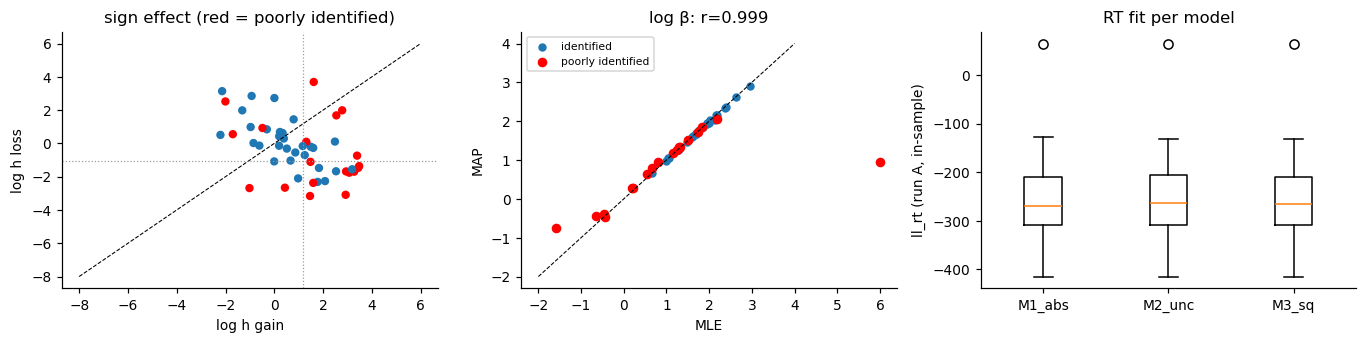

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.2))

# (a) sign effect, poorly identified in red
t = PARS_A["baseline"]
ax[0].scatter(t.log_h_gain, t.log_h_loss, s=20,
              c=np.where(POORLY_ID.reindex(t.index, fill_value=False), "r", "C0"))
ax[0].plot([-8, 6], [-8, 6], "k--", lw=.7)
ax[0].axvline(np.log(H_EMP[1]), color="0.6", lw=.8, ls=":")
ax[0].axhline(np.log(H_EMP[2]), color="0.6", lw=.8, ls=":")
ax[0].set(xlabel="log h gain", ylabel="log h loss",
          title="sign effect (red = poorly identified)")

# (b) priors do not move the well-identified estimates
ax[1].scatter(sub.log_beta_mle, sub.log_beta, s=20, label="identified")
ax[1].scatter(cmp.loc[POORLY_ID.values, "log_beta_mle"],
              cmp.loc[POORLY_ID.values, "log_beta"], s=28, c="r", label="poorly identified")
ax[1].plot([-2, 4], [-2, 4], "k--", lw=.7)
ax[1].set(xlabel="MLE", ylabel="MAP",
          title=f"log β: r={np.corrcoef(sub.log_beta, sub.log_beta_mle)[0,1]:.3f}")
ax[1].legend(fontsize=7)

# (c) in-sample RT fit (b itself is not comparable across models)
ax[2].boxplot([L[c] for c in L.columns])
ax[2].set_xticks(range(1, len(L.columns)+1)); ax[2].set_xticklabels(L.columns)
ax[2].set(ylabel="ll_rt (run A, in-sample)", title="RT fit per model")

plt.tight_layout(); savefig_show("fig2_insample")

## 4. Parameter recovery

### 4.1 Simulator

In [14]:
def simulate(pars, design, model, rng, tau_sec):
    """Generates choices and RTs from known parameters, over a real trial design."""
    d = design.copy().reset_index(drop=True)
    dv = compute_dv(pars, d)
    pu = choice_prob(pars, dv)
    d["y"] = (rng.random(len(d)) < pu).astype(float)
    d["choice"] = d.y + 1
    mu = rt_location(pars, model, dv, pu)
    d["rt"] = tau_sec + np.exp(mu + np.exp(pars["log_sigma"]) * rng.standard_normal(len(d)))
    return d[d.rt >= RT_LO].reset_index(drop=True)     # same cleaning as the real data

# generating ranges, informed by Step 3's estimates
GEN = dict(log_h_gain=(-2.0, 3.5), log_h_loss=(-3.0, 2.5),
           log_beta=(0.0, 2.9), beta0=(-2.0, 2.0),
           a=(0.2, 0.9), log_sigma=(-1.0, -0.2))       # 'b' is model-dependent
# M3's predictor (ΔV²) is ~3.5x smaller in scale than |ΔV|, so an equivalent effect on mu
# requires a proportionally larger b. Using one range for all models would simulate a
# near-null effect under M3 and make its recovery look artificially poor.
GEN_B = {"M1_abs": (-0.2, 1.0), "M2_unc": (-0.2, 1.0), "M3_sq": (-0.5, 3.0)}
TAU_RANGE = (0.10, 0.24)     # below the observed minimum RT (0.25 s)

def draw_true(rng, model):
    p = {k: rng.uniform(*v) for k, v in GEN.items()}
    p["b"] = rng.uniform(*GEN_B[model])
    return p, rng.uniform(*TAU_RANGE)

### 4.2 Recovery 

In [15]:
N_REC, N_RESTART_REC = 200, 5
DESIGN_COLS = ["r_cert", "r_unc", "theta", "condition", "scale"]

def recovery(model, n_rep=N_REC, seed=7):
    rng, rows, skipped = np.random.default_rng(seed), [], 0
    for i in range(n_rep):
        p_true, tau = draw_true(rng, model)
        sid = SUBJ[rng.integers(len(SUBJ))]
        design = data[(data.participant_id == sid) & (data.run == "A")][DESIGN_COLS]
        sim = simulate(p_true, design, model, rng, tau)
        # a replicate with almost no choice variance carries no information about h or beta
        if len(sim) < 100 or not (0.02 < sim.y.mean() < 0.98):
            skipped += 1
            continue
        f_full = fit_one(sim, model, use_rt=True,  n_restart=N_RESTART_REC,
                         seed=stable_seed("rec", model, i, "full"))
        f_cho  = fit_one(sim, None,  use_rt=False, n_restart=N_RESTART_REC,
                         seed=stable_seed("rec", model, i, "cho"))
        if f_full is None or f_cho is None:
            skipped += 1
            continue
        est_f = dict(f_full["pars"]); est_f["tau"] = get_tau(f_full["pars"], f_full["rt_min"])
        truth = dict(p_true); truth["tau"] = tau
        for n, v in truth.items():
            rows.append(dict(model=model, rep=i, param=n, true=v,
                             est_full=est_f.get(n, np.nan),
                             est_choice=f_cho["pars"].get(n, np.nan)))
    if skipped:
        print(f"  {model}: {skipped} replicates skipped")
    return pd.DataFrame(rows)

t0 = time.time()
REC = pd.concat([recovery(m) for m in RT_MODELS], ignore_index=True)
print(f"recovery completed in {time.time()-t0:.0f}s "
      f"({REC.groupby('model').rep.nunique().to_dict()} replicates)")

def stats(g, col):
    g = g.dropna(subset=["true", col])
    if len(g) < 5:
        return pd.Series(dict(r=np.nan, rmse=np.nan, bias=np.nan, n=len(g)))
    return pd.Series(dict(r=pearsonr(g["true"], g[col])[0],
                          rmse=np.sqrt(np.mean((g["true"] - g[col])**2)),
                          bias=np.mean(g[col] - g["true"]), n=len(g)))

REC_FULL = REC.groupby(["model","param"])[["true","est_full"]].apply(stats, col="est_full").round(3)
print("\n=== recovery with RT (choice + RT) ===")
print(REC_FULL)
print("\nNOTE: b was generated on a model-specific range, so its RMSE is not comparable "
      "across models; the correlation r is.")

recovery completed in 309s ({'M1_abs': 200, 'M2_unc': 200, 'M3_sq': 200} replicates)

=== recovery with RT (choice + RT) ===
                       r   rmse   bias      n
model  param                                 
M1_abs a           0.884  0.107 -0.036  200.0
       b           0.897  0.184  0.028  200.0
       beta0       0.954  0.371 -0.036  200.0
       log_beta    0.955  0.266  0.041  200.0
       log_h_gain  0.925  0.569 -0.063  200.0
       log_h_loss  0.958  0.486  0.082  200.0
       log_sigma   0.917  0.097  0.032  200.0
       tau         0.187  0.110  0.055  200.0
M2_unc a           0.825  0.145 -0.018  200.0
       b           0.860  0.210  0.034  200.0
       beta0       0.952  0.382 -0.040  200.0
       log_beta    0.958  0.253  0.062  200.0
       log_h_gain  0.900  0.649 -0.074  200.0
       log_h_loss  0.936  0.598  0.118  200.0
       log_sigma   0.914  0.098  0.028  200.0
       tau         0.207  0.103  0.049  200.0
M3_sq  a           0.928  0.086 -0.035  200.0
 

### 4.3 Analysis


In [16]:
REC_CHO = (REC[REC.param.isin(CHOICE_PARS)]
           .groupby(["model","param"])[["true","est_choice"]]
           .apply(stats, col="est_choice").round(3))

CMP = (REC_FULL.loc[:, ["r","rmse"]]
       .join(REC_CHO.loc[:, ["r","rmse"]], lsuffix="_rt", rsuffix="_choice", how="inner"))
CMP["Δr"] = (CMP.r_rt - CMP.r_choice).round(3)
CMP["rmse_ratio"] = (CMP.rmse_rt / CMP.rmse_choice).round(3)   # <1 = RT helps
print("=== with RT vs. choice-only (rmse_ratio < 1 = RT improves recovery) ===")
print(CMP)

print("\n=== paired test (Wilcoxon on |error|) ===")
rows = []
for m in RT_MODELS:
    for p in CHOICE_PARS:
        g = REC[(REC.model == m) & (REC.param == p)].dropna()
        e_rt, e_so = (g.est_full - g["true"]).abs(), (g.est_choice - g["true"]).abs()
        pv = wilcoxon(e_rt, e_so)[1]
        rows.append(dict(model=m, param=p, err_rt=e_rt.median(),
                         err_choice=e_so.median(), better=int((e_rt < e_so).sum()),
                         n=len(g), p=pv))
        print(f"{m:8s} {p:12s}: |err| RT={e_rt.median():.3f} "
              f"choice-only={e_so.median():.3f}  p={pv:.4f}")
RT_HELPS_REC = pd.DataFrame(rows).round(4)

=== with RT vs. choice-only (rmse_ratio < 1 = RT improves recovery) ===
                    r_rt  rmse_rt  r_choice  rmse_choice     Δr  rmse_ratio
model  param                                                               
M1_abs beta0       0.954    0.371     0.940        0.427  0.014       0.869
       log_beta    0.955    0.266     0.951        0.276  0.004       0.964
       log_h_gain  0.925    0.569     0.899        0.660  0.026       0.862
       log_h_loss  0.958    0.486     0.917        0.676  0.041       0.719
M2_unc beta0       0.952    0.382     0.940        0.427  0.012       0.895
       log_beta    0.958    0.253     0.951        0.276  0.007       0.917
       log_h_gain  0.900    0.649     0.899        0.660  0.001       0.983
       log_h_loss  0.936    0.598     0.917        0.677  0.019       0.883
M3_sq  beta0       0.963    0.326     0.940        0.429  0.023       0.760
       log_beta    0.956    0.263     0.948        0.285  0.008       0.923
       log_h_gai

In [17]:
print("=== tau/a trade-off (why tau is not identifiable) ===")
for m in RT_MODELS:
    sub = REC[REC.model == m]
    T = sub.pivot(index="rep", columns="param", values="true")
    E = sub.pivot(index="rep", columns="param", values="est_full")
    err = pd.DataFrame({"tau": E.tau - T.tau, "a": E.a - T.a}).dropna()
    print(f"{m:8s}: r(tau)={pearsonr(T.tau.dropna(), E.tau.dropna())[0]:+.3f}  "
          f"corr(err_tau, err_a)={err.tau.corr(err.a):+.3f}  "
          f"bias_tau={err.tau.mean():+.4f}s")

=== tau/a trade-off (why tau is not identifiable) ===
M1_abs  : r(tau)=+0.187  corr(err_tau, err_a)=-0.638  bias_tau=+0.0549s
M2_unc  : r(tau)=+0.207  corr(err_tau, err_a)=-0.381  bias_tau=+0.0485s
M3_sq   : r(tau)=+0.287  corr(err_tau, err_a)=-0.635  bias_tau=+0.0477s


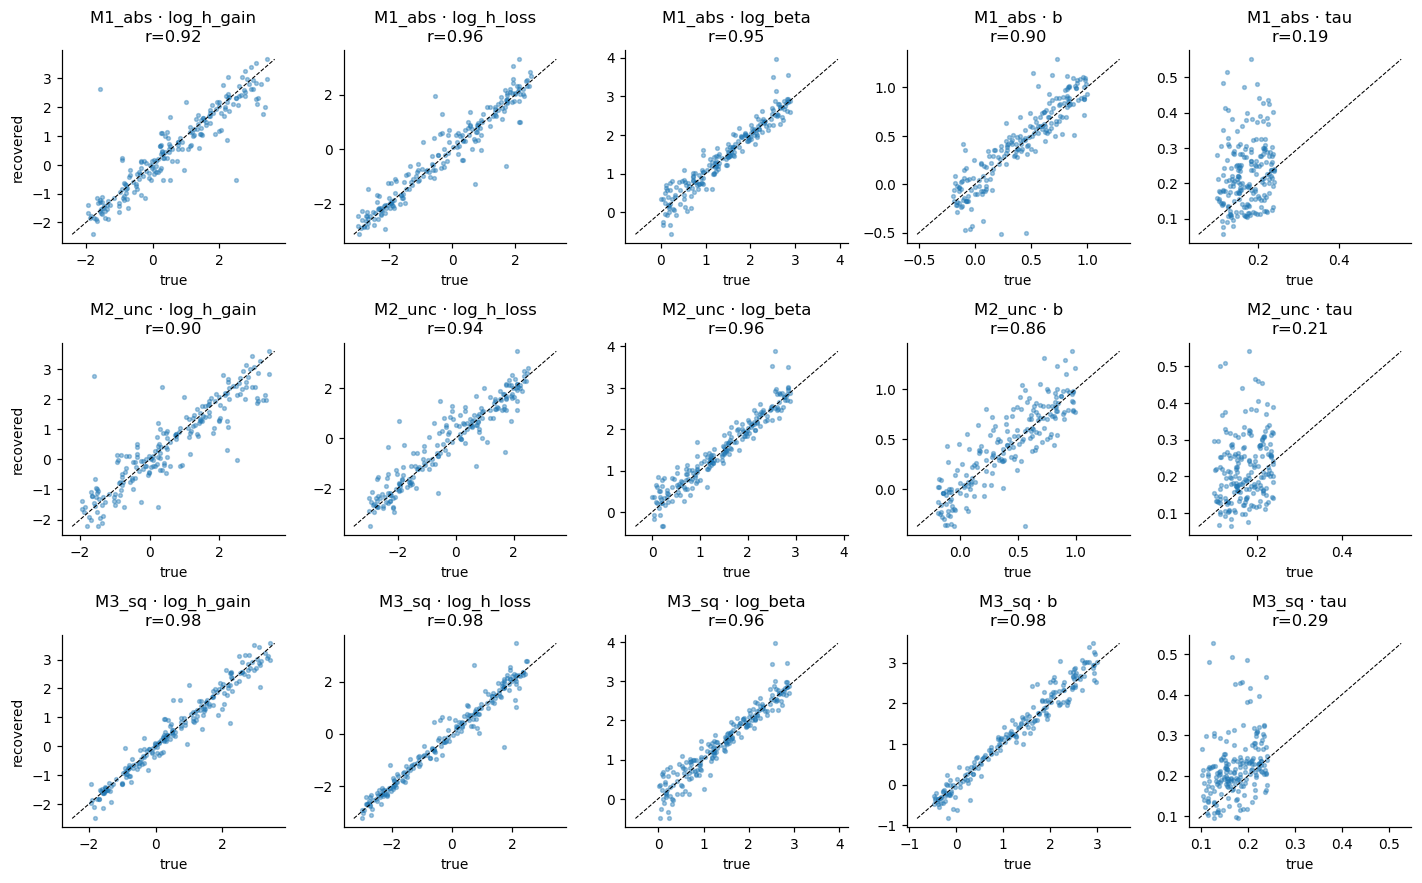

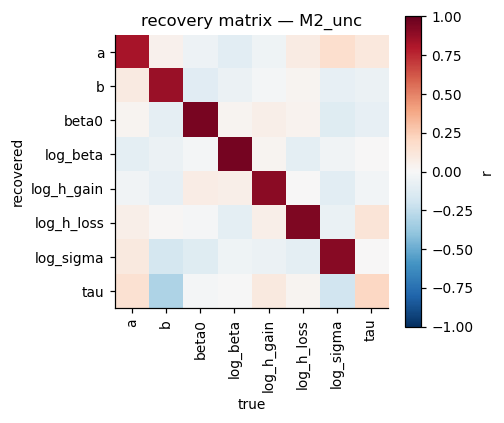

               a     b  beta0  log_beta  log_h_gain  log_h_loss  log_sigma  \
param                                                                        
a           0.82  0.04  -0.05     -0.11       -0.05        0.08       0.17   
b           0.09  0.86  -0.11     -0.06       -0.02        0.02      -0.08   
beta0       0.02 -0.09   0.95      0.03        0.06        0.04      -0.12   
log_beta   -0.10 -0.06  -0.02      0.96        0.03       -0.10      -0.03   
log_h_gain -0.04 -0.08   0.07      0.06        0.90        0.01      -0.10   
log_h_loss  0.06  0.01  -0.01     -0.10        0.06        0.94      -0.07   
log_sigma   0.10 -0.18  -0.12     -0.04       -0.06       -0.10       0.91   
tau         0.15 -0.31  -0.02     -0.00        0.10        0.03      -0.19   

             tau  
param             
a           0.10  
b          -0.06  
beta0      -0.08  
log_beta    0.01  
log_h_gain -0.03  
log_h_loss  0.13  
log_sigma   0.00  
tau         0.21  


In [18]:
PLOT_PARS = ["log_h_gain", "log_h_loss", "log_beta", "b", "tau"]
fig, axes = plt.subplots(len(RT_MODELS), len(PLOT_PARS),
                         figsize=(2.6*len(PLOT_PARS), 2.7*len(RT_MODELS)))
for row, m in enumerate(RT_MODELS):
    sub = REC[REC.model == m]
    for col, p in enumerate(PLOT_PARS):
        a_ = axes[row, col]
        g = sub[sub.param == p].dropna(subset=["true", "est_full"])
        a_.scatter(g["true"], g.est_full, s=6, alpha=.4)
        lim = [g[["true","est_full"]].values.min(), g[["true","est_full"]].values.max()]
        a_.plot(lim, lim, "k--", lw=.7)
        a_.set(title=f"{m} · {p}\nr={pearsonr(g['true'], g.est_full)[0]:.2f}",
               xlabel="true", ylabel="recovered" if col == 0 else "")
plt.tight_layout(); savefig_show("fig3_recovery")

# recovery matrix for the best in-sample model: off-diagonal = parameter trade-offs
m0 = "M2_unc"
sub = REC[REC.model == m0]
T = sub.pivot(index="rep", columns="param", values="true")
E = sub.pivot(index="rep", columns="param", values="est_full")
M = pd.DataFrame({c: [pd.concat([T[c], E[r]], axis=1).dropna().corr().iloc[0, 1]
                      for r in E.columns] for c in T.columns}, index=E.columns)
plt.figure(figsize=(4.6, 4))
plt.imshow(M.values, vmin=-1, vmax=1, cmap="RdBu_r")
plt.xticks(range(len(M.columns)), M.columns, rotation=90)
plt.yticks(range(len(M.index)), M.index)
plt.xlabel("true"); plt.ylabel("recovered"); plt.colorbar(label="r")
plt.title(f"recovery matrix — {m0}")
plt.tight_layout(); savefig_show("fig4_recovery_matrix")
print(M.round(2))

## 5. Reliability

In [19]:
t0 = time.time()
FITS_B = fit_all(models=ALL_MODELS, runs=("B",), n_restart=10)
for m in ALL_MODELS:
    FITS[m]["B"] = FITS_B[m]["B"]
PARS_B = {m: par_table(FITS, m, "B") for m in ALL_MODELS}
print(f"run B fitted in {time.time()-t0:.0f}s")
print("convergence:", {m: f"{PARS_B[m].conv.mean():.0%}" for m in ALL_MODELS})


baseline   done in   4.8s


M1_abs     done in  26.8s


M2_unc     done in  29.5s


M3_sq      done in  22.4s
run B fitted in 83s
convergence: {'baseline': '100%', 'M1_abs': '100%', 'M2_unc': '96%', 'M3_sq': '100%'}


In [20]:
def icc21(x, y):
    """ICC(2,1): absolute agreement, single measurement."""
    M = np.column_stack([x, y]); n, k = M.shape
    gm  = M.mean()
    MSR = k * ((M.mean(1) - gm)**2).sum() / (n - 1)
    MSC = n * ((M.mean(0) - gm)**2).sum() / (k - 1)
    MSE = ((M - M.mean(1, keepdims=True) - M.mean(0, keepdims=True) + gm)**2).sum() / ((n-1)*(k-1))
    return (MSR - MSE) / (MSR + (k-1)*MSE + k*(MSC - MSE)/n)

def boot_ci(x, y, n_boot=2000, seed=0):
    rng, vals = np.random.default_rng(seed), []
    for _ in range(n_boot):
        i = rng.integers(0, len(x), len(x))
        try: vals.append(pearsonr(x[i], y[i])[0])
        except Exception: pass
    return np.nanpercentile(vals, [2.5, 97.5])

def boot_dif(model, ref, param, n_boot=2000, seed=0):
    """Bootstrap CI for the reliability-r DIFFERENCE, model vs ref, for one parameter.
    Resamples participants once per draw and applies it to both models, so the paired
    structure (both correlations computed on the same participants) is preserved."""
    idx = (PARS_A[model].index.intersection(PARS_B[model].index)
           .intersection(PARS_A[ref].index).intersection(PARS_B[ref].index))
    d = pd.concat([
        PARS_A[model].loc[idx, param].rename("Am"), PARS_B[model].loc[idx, param].rename("Bm"),
        PARS_A[ref].loc[idx, param].rename("Ar"),   PARS_B[ref].loc[idx, param].rename("Br"),
    ], axis=1).dropna()
    x_m, y_m, x_r, y_r = d.Am.values, d.Bm.values, d.Ar.values, d.Br.values
    point = pearsonr(x_m, y_m)[0] - pearsonr(x_r, y_r)[0]
    rng, diffs = np.random.default_rng(seed), []
    for _ in range(n_boot):
        i = rng.integers(0, len(d), len(d))
        try:
            diffs.append(pearsonr(x_m[i], y_m[i])[0] - pearsonr(x_r[i], y_r[i])[0])
        except Exception:
            pass
    lo, hi = np.nanpercentile(diffs, [2.5, 97.5])
    return point, lo, hi

REL_PARS = ["log_h_gain", "log_h_loss", "log_beta", "beta0", "a", "b", "log_sigma", "tau"]

def reliability(model, subset=None, n_boot=2000):
    A, B = PARS_A[model], PARS_B[model]
    idx = A.index.intersection(B.index)
    if subset is not None:
        idx = idx.intersection(subset)
    rows = []
    for p in [c for c in REL_PARS if c in A.columns and c in B.columns]:
        d = pd.concat([A.loc[idx, p].rename("A"), B.loc[idx, p].rename("B")], axis=1).dropna()
        if len(d) < 8: continue
        x, y = d.A.values, d.B.values
        ci = boot_ci(x, y, n_boot)
        rows.append(dict(model=model, param=p, n=len(d),
                         r=pearsonr(x, y)[0], r_lo=ci[0], r_hi=ci[1],
                         rho=spearmanr(x, y)[0], icc=icc21(x, y)))
    return pd.DataFrame(rows)

RELI = pd.concat([reliability(m) for m in ALL_MODELS], ignore_index=True).round(3)

print("=== test-retest reliability ===")
print("Pearson r:");  print(RELI.pivot(index="param", columns="model", values="r"))
print("\nSpearman rho:"); print(RELI.pivot(index="param", columns="model", values="rho"))
print("\nbootstrap CI (baseline):")
print(RELI[RELI.model == "baseline"][["param","n","r","r_lo","r_hi","rho","icc"]].to_string(index=False))

# Pearson vs Spearman: large divergence = influence of extreme values
div = RELI.assign(dif=(RELI.r - RELI.rho).round(3))
print("\nparameters with |r - rho| > 0.10 (report Spearman instead):")
print(div[div.dif.abs() > 0.10][["model","param","r","rho","dif"]].to_string(index=False))


=== test-retest reliability ===
Pearson r:
model       M1_abs  M2_unc  M3_sq  baseline
param                                      
a            0.682   0.616  0.727       NaN
b            0.089   0.199  0.100       NaN
beta0        0.092   0.164  0.276     0.361
log_beta     0.560   0.504  0.532     0.575
log_h_gain   0.212   0.187  0.447     0.444
log_h_loss   0.118   0.099  0.304     0.124
log_sigma    0.666   0.670  0.669       NaN
tau          0.414   0.389  0.407       NaN

Spearman rho:
model       M1_abs  M2_unc  M3_sq  baseline
param                                      
a            0.606   0.661  0.669       NaN
b            0.129   0.316  0.070       NaN
beta0        0.204   0.200  0.329     0.313
log_beta     0.662   0.643  0.649     0.666
log_h_gain   0.225   0.163  0.423     0.437
log_h_loss   0.089   0.169  0.228     0.114
log_sigma    0.460   0.489  0.462       NaN
tau          0.419   0.383  0.407       NaN

bootstrap CI (baseline):
     param  n     r   r_lo  r_hi   r

In [21]:
# (1) does RT improve or worsen the stability of the choice parameters?
piv = RELI[RELI.param.isin(CHOICE_PARS)].pivot(index="param", columns="model", values="r")
for m in RT_MODELS:
    piv[f"Δ {m}"] = (piv[m] - piv["baseline"]).round(3)
print("=== effect of RT on reliability (Δ < 0 = worsens) ===")
print(piv.round(3))

# (2) is the effect concentrated in the poorly-identified participants?
well_id = [s for s in SUBJ if s in POORLY_ID.index and not POORLY_ID[s]]
comp = []
for m in ALL_MODELS:
    t = reliability(m, n_boot=500).set_index("param").r
    s = reliability(m, subset=well_id, n_boot=500).set_index("param").r
    comp.append(pd.DataFrame({(m, "all"): t, (m, "well_id"): s}))
COMP_ID = pd.concat(comp, axis=1).round(3)
COMP_ID.columns = pd.MultiIndex.from_tuples(COMP_ID.columns)
print(f"\n=== all (n=49) vs well-identified (n={len(well_id)}) ===")
print(COMP_ID)


=== effect of RT on reliability (Δ < 0 = worsens) ===
model       M1_abs  M2_unc  M3_sq  baseline  Δ M1_abs  Δ M2_unc  Δ M3_sq
param                                                                   
beta0        0.092   0.164  0.276     0.361    -0.269    -0.197   -0.085
log_beta     0.560   0.504  0.532     0.575    -0.015    -0.071   -0.043
log_h_gain   0.212   0.187  0.447     0.444    -0.232    -0.257    0.003
log_h_loss   0.118   0.099  0.304     0.124    -0.006    -0.025    0.180



=== all (n=49) vs well-identified (n=30) ===
           baseline         M1_abs         M2_unc          M3_sq        
                all well_id    all well_id    all well_id    all well_id
param                                                                   
log_h_gain    0.444   0.426  0.212   0.422  0.187   0.281  0.447   0.518
log_h_loss    0.124   0.201  0.118   0.313  0.099   0.159  0.304   0.305
log_beta      0.575   0.624  0.560   0.568  0.504   0.540  0.532   0.527
beta0         0.361   0.366  0.092   0.201  0.164   0.249  0.276   0.441
a               NaN     NaN  0.682   0.629  0.616   0.635  0.727   0.678
b               NaN     NaN  0.089   0.057  0.199   0.240  0.100   0.044
log_sigma       NaN     NaN  0.666   0.391  0.670   0.393  0.669   0.386
tau             NaN     NaN  0.414   0.421  0.389   0.386  0.407   0.404


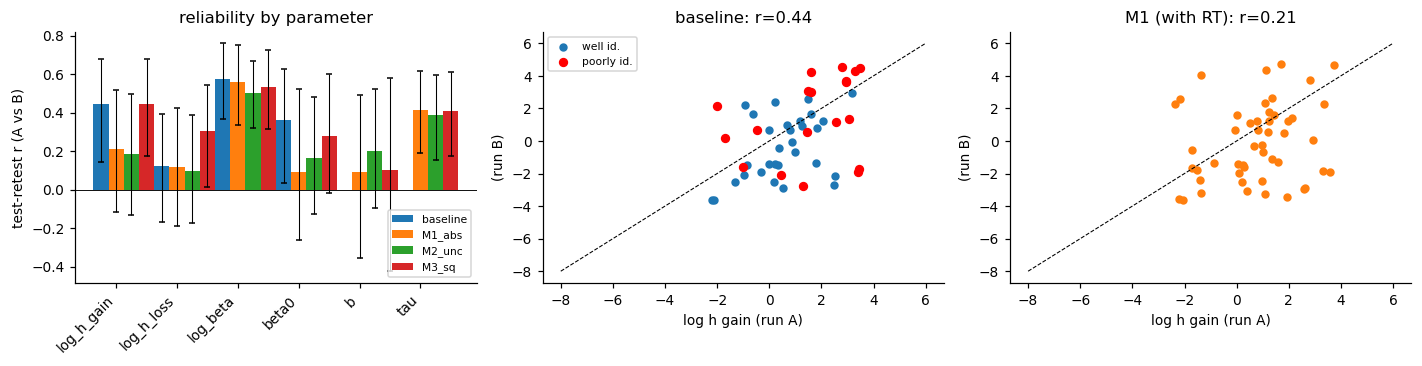

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))

# (a) reliability by parameter and model, with bootstrap CI
prm = ["log_h_gain", "log_h_loss", "log_beta", "beta0", "b", "tau"]
w, x = 0.25, np.arange(len(prm))
for i, m in enumerate(ALL_MODELS):
    d = RELI[RELI.model == m].set_index("param").reindex(prm)
    ax[0].bar(x + i*w - w, d.r, w, label=m,
              yerr=[d.r - d.r_lo, d.r_hi - d.r], capsize=2, error_kw=dict(lw=.7))
ax[0].set_xticks(x); ax[0].set_xticklabels(prm, rotation=45, ha="right")
ax[0].axhline(0, color="k", lw=.6)
ax[0].set(ylabel="test-retest r (A vs B)", title="reliability by parameter")
ax[0].legend(fontsize=7)

# (b) central finding: RT reduces the stability of log h -- the well-identified-subset
# check above shows this is only partly explained by the poorly-identified participants
A, B = PARS_A["baseline"], PARS_B["baseline"]
idx = A.index.intersection(B.index)
poorly_id = POORLY_ID.reindex(idx, fill_value=False).values
ax[1].scatter(A.loc[idx,"log_h_gain"][~poorly_id], B.loc[idx,"log_h_gain"][~poorly_id], s=20, label="well id.")
ax[1].scatter(A.loc[idx,"log_h_gain"][poorly_id],  B.loc[idx,"log_h_gain"][poorly_id],  s=26, c="r", label="poorly id.")
ax[1].plot([-8, 6], [-8, 6], "k--", lw=.7)
ax[1].set(xlabel="log h gain (run A)", ylabel="(run B)",
          title=f"baseline: r={pearsonr(A.loc[idx,'log_h_gain'], B.loc[idx,'log_h_gain'])[0]:.2f}")
ax[1].legend(fontsize=7)

A1, B1 = PARS_A["M1_abs"], PARS_B["M1_abs"]
i1 = A1.index.intersection(B1.index)
ax[2].scatter(A1.loc[i1,"log_h_gain"], B1.loc[i1,"log_h_gain"], s=20, c="C1")
ax[2].plot([-8, 6], [-8, 6], "k--", lw=.7)
ax[2].set(xlabel="log h gain (run A)", ylabel="(run B)",
          title=f"M1 (with RT): r={pearsonr(A1.loc[i1,'log_h_gain'], B1.loc[i1,'log_h_gain'])[0]:.2f}")

plt.tight_layout(); savefig_show("fig5_reliability")


## 6. Evaluate and compare out-of-sample (run B)

In [23]:
def auc_score(y, p):
    y, p = np.asarray(y), np.asarray(p)
    n1, n0 = y.sum(), (1 - y).sum()
    if n1 == 0 or n0 == 0: return np.nan
    r = pd.Series(p).rank().values
    return float((r[y == 1].sum() - n1*(n1+1)/2) / (n1*n0))

def predict_runB(model, sid):
    """Applies run A parameters to run B trials. Nothing is re-fitted here."""
    f = FITS[model]["A"][sid]
    if f is None: return []
    mdl  = None if model == "baseline" else model
    d    = data[(data.participant_id == sid) & (data.run == "B")]
    pars = f["pars"]
    rt_min = f["rt_min"]          # run A's minimum: tau stays fixed in seconds

    dv  = compute_dv(pars, d)
    pu  = choice_prob(pars, dv)
    llc = ll_choice(pars, d, dv, pu)
    if mdl is not None:
        llr = ll_rt(pars, mdl, d, dv, pu, rt_min)
        tau, mu = get_tau(pars, rt_min), rt_location(pars, mdl, dv, pu)

    rows = []
    for cname, msk in [("all",    np.ones(len(d), bool)),
                       ("reward", d.condition.values == 1),
                       ("loss",   d.condition.values == 2)]:
        if msk.sum() < 5: continue
        y, p = d.y.values[msk], pu[msk]
        pred = (p > .5).astype(float)
        bacc = np.nanmean([(pred[y == c] == c).mean() if (y == c).sum() else np.nan
                           for c in (0, 1)])
        row = dict(sid=sid, model=model, cond=cname, n=int(msk.sum()),
                   llc=float(llc[msk].mean()), acc=float((pred == y).mean()),
                   bacc=float(bacc), auc=auc_score(y, p))
        if mdl is not None:
            rt = d.rt.values[msk]; ok = rt > tau
            row.update(llrt=float(llr[msk].mean()),
                       rt_rmse=float(np.sqrt(np.mean((np.log(rt[ok]-tau) - mu[msk][ok])**2)))
                                if ok.any() else np.nan,
                       tau_viol=float((~ok).mean()))
        rows.append(row)
    return rows

EVAL = pd.DataFrame([r for m in ALL_MODELS for s in SUBJ for r in predict_runB(m, s)])

print("=== run B predictive performance (participant means) ===")
print(EVAL.groupby(["model","cond"])[["llc","acc","bacc","auc","llrt","rt_rmse","tau_viol"]]
      .mean().round(4))
print("\ntrials with RT <= tau (floored at LL_FLOOR):",
      EVAL[EVAL.cond=="all"].groupby("model").tau_viol.mean().round(4).dropna().to_dict())

=== run B predictive performance (participant means) ===
                    llc     acc    bacc     auc    llrt  rt_rmse  tau_viol
model    cond                                                             
M1_abs   all    -0.6399  0.6974  0.6922  0.7521 -1.5484   0.7745    0.0025
         loss   -0.6294  0.7107  0.6903  0.7702 -1.4807   0.7409    0.0021
         reward -0.6500  0.6841  0.6895  0.7456 -1.6159   0.7938    0.0029
M2_unc   all    -0.6427  0.6944  0.6897  0.7499 -1.5243   0.7607    0.0028
         loss   -0.6337  0.7105  0.6915  0.7743 -1.5021   0.7402    0.0023
         reward -0.6511  0.6783  0.6826  0.7392 -1.5462   0.7694    0.0033
M3_sq    all    -0.6400  0.6954  0.6889  0.7542 -1.5442   0.7807    0.0028
         loss   -0.6334  0.7068  0.6869  0.7641 -1.4922   0.7483    0.0023
         reward -0.6461  0.6841  0.6885  0.7494 -1.5957   0.7966    0.0033
baseline all    -0.6300  0.7039  0.6986  0.7563     NaN      NaN       NaN
         loss   -0.6227  0.7177  0.6966  0.

In [24]:
def paired(metric, models, cond="all"):
    W = (EVAL[(EVAL.cond == cond) & (EVAL.model.isin(models))]
         .pivot(index="sid", columns="model", values=metric).dropna())
    ref = W.mean().idxmax()
    rows = []
    for m in W.columns:
        dif = W[m] - W[ref]
        p = wilcoxon(W[m], W[ref])[1] if (m != ref and np.any(dif != 0)) else np.nan
        rows.append(dict(model=m, mean=W[m].mean(), sem=W[m].sem(),
                         dif_vs_best=dif.mean(), wins=int((dif > 0).sum()),
                         n=len(W), p=p))
    return W, pd.DataFrame(rows).set_index("model").round(4), ref

print("### RT models compared on the RT predictive log-likelihood (run B) ###")
print("They share the same choice term, so the difference isolates the value→RT mapping.\n")
for cond in ["all", "reward", "loss"]:
    W, tab, ref = paired("llrt", RT_MODELS, cond)
    print(f"--- condition: {cond} (best: {ref}) ---"); print(tab, "\n")

# all pairwise tests, not just against the best
W_rt, TAB_RT, BEST_RT = paired("llrt", RT_MODELS, "all")
print("pairwise Wilcoxon (RT predictive LL, all trials):")
P = pd.DataFrame(index=RT_MODELS, columns=RT_MODELS, dtype=float)
for m1 in RT_MODELS:
    for m2 in RT_MODELS:
        if m1 != m2:
            P.loc[m1, m2] = wilcoxon(W_rt[m1], W_rt[m2])[1]
print(P.round(3))

print("\nRMSE on log RT (lower is better):")
print(EVAL[EVAL.cond=="all"].groupby("model").rt_rmse.mean().round(4).dropna().to_dict())

# in-sample vs out-of-sample: does the in-sample ranking generalise?
L_in = pd.DataFrame({m: PARS_A[m].ll_rt / PARS_A[m].index.map(
    lambda s: FITS[m]["A"][s]["n_trial"]) for m in RT_MODELS})
print("\nin-sample (run A) vs out-of-sample (run B), mean ll_rt per trial:")
print(pd.DataFrame({"in_sample": L_in.mean(), "out_of_sample": W_rt.mean()}).round(4))

### RT models compared on the RT predictive log-likelihood (run B) ###
They share the same choice term, so the difference isolates the value→RT mapping.

--- condition: all (best: M2_unc) ---
          mean     sem  dif_vs_best  wins   n       p
model                                                
M1_abs -1.5484  0.1422      -0.0241    25  49  0.8437
M2_unc -1.5243  0.1230       0.0000     0  49     NaN
M3_sq  -1.5442  0.1294      -0.0200    21  49  0.4124 

--- condition: reward (best: M2_unc) ---
          mean     sem  dif_vs_best  wins   n       p
model                                                
M1_abs -1.6159  0.1803      -0.0697    23  49  0.7006
M2_unc -1.5462  0.1398       0.0000     0  49     NaN
M3_sq  -1.5957  0.1610      -0.0495    25  49  0.7901 

--- condition: loss (best: M1_abs) ---
          mean     sem  dif_vs_best  wins   n       p
model                                                
M1_abs -1.4807  0.1128       0.0000     0  49     NaN
M2_unc -1.5021  0.1145

In [25]:
print("=== choice prediction quality (run B), by condition ===")
print(EVAL.groupby(["model","cond"])[["llc","acc","bacc","auc"]].mean().round(4))
print(f"\nchance level: llc = {np.log(0.5):.4f}")

# per-participant spread, to see whether the group mean hides heterogeneity
d = EVAL[(EVAL.cond=="all") & (EVAL.model=="baseline")]
print("\nbaseline AUC across participants:",
      d.auc.describe([.1, .5, .9]).round(3).to_dict())
print(f"participants with AUC < 0.6: {(d.auc < 0.6).sum()} of {len(d)}")

=== choice prediction quality (run B), by condition ===
                    llc     acc    bacc     auc
model    cond                                  
M1_abs   all    -0.6399  0.6974  0.6922  0.7521
         loss   -0.6294  0.7107  0.6903  0.7702
         reward -0.6500  0.6841  0.6895  0.7456
M2_unc   all    -0.6427  0.6944  0.6897  0.7499
         loss   -0.6337  0.7105  0.6915  0.7743
         reward -0.6511  0.6783  0.6826  0.7392
M3_sq    all    -0.6400  0.6954  0.6889  0.7542
         loss   -0.6334  0.7068  0.6869  0.7641
         reward -0.6461  0.6841  0.6885  0.7494
baseline all    -0.6300  0.7039  0.6986  0.7563
         loss   -0.6227  0.7177  0.6966  0.7674
         reward -0.6368  0.6902  0.6891  0.7435

chance level: llc = -0.6931

baseline AUC across participants: {'count': 49.0, 'mean': 0.756, 'std': 0.167, 'min': 0.156, '10%': 0.563, '50%': 0.819, '90%': 0.908, 'max': 0.975}
participants with AUC < 0.6: 7 of 49


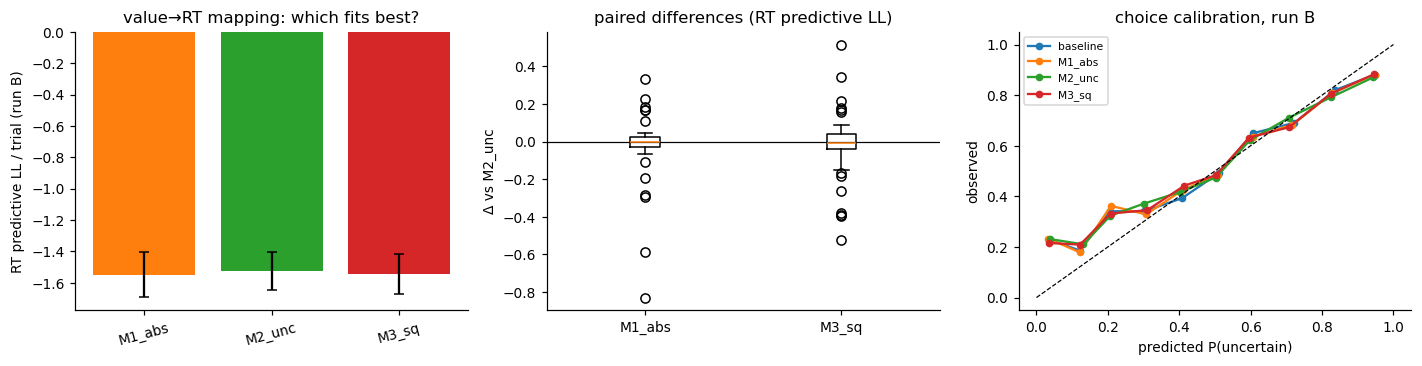

In [26]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))

# (a) RT predictive LL per model
ax[0].bar(TAB_RT.index, TAB_RT["mean"], yerr=TAB_RT["sem"],
          color=["C1","C2","C3"][:len(RT_MODELS)], capsize=3)
ax[0].set(ylabel="RT predictive LL / trial (run B)",
          title="value→RT mapping: which fits best?")
ax[0].tick_params(axis="x", rotation=15)

# (b) paired differences against the best model
dif = W_rt.drop(columns=BEST_RT).sub(W_rt[BEST_RT], axis=0)
ax[1].boxplot([dif[c] for c in dif.columns])
ax[1].set_xticks(range(1, len(dif.columns)+1)); ax[1].set_xticklabels(dif.columns)
ax[1].axhline(0, color="k", lw=.8)
ax[1].set(ylabel=f"Δ vs {BEST_RT}", title="paired differences (RT predictive LL)")

# (c) choice calibration
for m in ALL_MODELS:
    ps, ys = [], []
    for s in SUBJ:
        f = FITS[m]["A"][s]
        if f is None: continue
        db = data[(data.participant_id == s) & (data.run == "B")]
        ps.append(choice_prob(f["pars"], compute_dv(f["pars"], db))); ys.append(db.y.values)
    ps, ys = np.concatenate(ps), np.concatenate(ys)
    b = pd.qcut(pd.Series(ps), 10, duplicates="drop")
    ax[2].plot(pd.Series(ps).groupby(b, observed=True).mean(),
               pd.Series(ys).groupby(b, observed=True).mean(), "o-", ms=4, label=m)
ax[2].plot([0,1],[0,1], "k--", lw=.8)
ax[2].set(xlabel="predicted P(uncertain)", ylabel="observed", title="choice calibration, run B")
ax[2].legend(fontsize=7)

plt.tight_layout(); savefig_show("fig6_prediction")

## 7. Does RT help? 

### DOES RT HELP? (a) OUT-OF-SAMPLE CHOICE PREDICTION ###
Compared on CHOICE quantities only. The joint and choice-only likelihoods describe
different data, so their totals are not comparable; the choice term is.

  cond metric  model  baseline  with_rt   delta  better  n      p
   all    llc M1_abs   -0.6300  -0.6399 -0.0099      20 49 0.1190
   all    llc M2_unc   -0.6300  -0.6427 -0.0127      18 49 0.0531
   all    llc  M3_sq   -0.6300  -0.6400 -0.0100      19 49 0.1143
   all   bacc M1_abs    0.6986   0.6922 -0.0064      18 49 0.6893
   all   bacc M2_unc    0.6986   0.6897 -0.0088      19 49 0.6967
   all   bacc  M3_sq    0.6986   0.6889 -0.0097      18 49 0.3268
reward    llc M1_abs   -0.6368  -0.6500 -0.0132      20 49 0.1143
reward    llc M2_unc   -0.6368  -0.6511 -0.0142      17 49 0.1190
reward    llc  M3_sq   -0.6368  -0.6461 -0.0093      23 49 0.4958
reward   bacc M1_abs    0.6891   0.6895  0.0004      16 49 0.2059
reward   bacc M2_unc    0.6891   0.6826 -0.0066      15 49 0

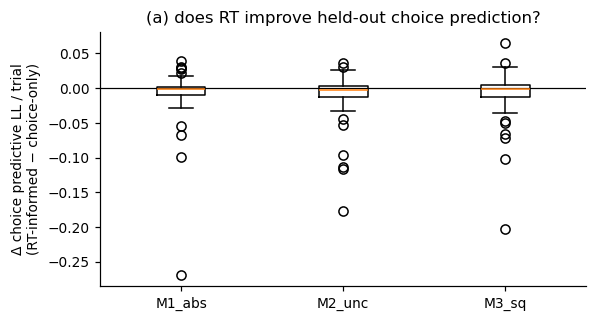

In [27]:
print("### DOES RT HELP? (a) OUT-OF-SAMPLE CHOICE PREDICTION ###")
print("Compared on CHOICE quantities only. The joint and choice-only likelihoods describe")
print("different data, so their totals are not comparable; the choice term is.\n")

rows = []
for cond in ["all", "reward", "loss"]:
    for met in ["llc", "acc", "bacc", "auc"]:
        d = EVAL[EVAL.cond == cond].pivot(index="sid", columns="model", values=met).dropna()
        for m in RT_MODELS:
            dif = d[m] - d["baseline"]
            p = wilcoxon(d[m], d["baseline"])[1] if np.any(dif != 0) else np.nan
            rows.append(dict(cond=cond, metric=met, model=m,
                             baseline=d["baseline"].mean(), with_rt=d[m].mean(),
                             delta=dif.mean(), better=int((dif > 0).sum()), n=len(d), p=p))
RT_HELPS_CHOICE = pd.DataFrame(rows).round(4)
print(RT_HELPS_CHOICE[RT_HELPS_CHOICE.metric.isin(["llc","bacc"])].to_string(index=False))

d = EVAL[EVAL.cond=="all"].pivot(index="sid", columns="model", values="llc").dropna()
difc = d[RT_MODELS].sub(d["baseline"], axis=0)
plt.figure(figsize=(5.5, 3))
plt.boxplot([difc[c] for c in difc.columns])
plt.xticks(range(1, len(difc.columns)+1), difc.columns)
plt.axhline(0, color="k", lw=.8)
plt.ylabel("Δ choice predictive LL / trial\n(RT-informed − choice-only)")
plt.title("(a) does RT improve held-out choice prediction?")
plt.tight_layout(); savefig_show("fig7_rt_choice")

In [28]:
print("### DOES RT HELP? (b) RECOVERY AND RELIABILITY ###\n")

print("--- b1. parameter recovery (simulation: RMSE ratio, <1 = RT helps) ---")
print(CMP[["rmse_ratio", "Δr"]].unstack(0).round(3))

print("\n--- b2. recovery by effect size (why the simulation and the data disagree) ---")
slope_rows = []
for s in SUBJ:
    f = FITS["M1_abs"]["A"][s]
    if f is None: continue
    d = data[(data.participant_id == s) & (data.run == "A") & (data.condition == 1)]
    if len(d) < 5: continue
    dv = compute_dv(f["pars"], d)
    slope_rows.append(pd.DataFrame({"sid": s, "absdv": np.abs(dv), "logrt": np.log(d.rt.values)}))
sl = pd.concat(slope_rows, ignore_index=True)
sl["absdv_c"] = sl.groupby("sid").absdv.transform(lambda x: x - x.mean())
sl["logrt_c"] = sl.groupby("sid").logrt.transform(lambda x: x - x.mean())
slope_within = np.polyfit(sl.absdv_c, sl.logrt_c, 1)[0]
slope_raw    = np.polyfit(sl.absdv, sl.logrt, 1)[0]
print("With a weak difficulty effect -- the regime the real data occupy -- RT adds little")
print(f"under M1/M2. Real slope of log RT on |ΔV| (gains, M1's fitted h): "
      f"{slope_within:+.3f} within-participant / {slope_raw:+.3f} raw pooled -- both far")
print("smaller in magnitude than the effect sizes GEN_B draws for recovery, and small")
print("enough that even the sign is sensitive to how participant-level RT offsets are handled.")

print("\n--- b3. test-retest reliability (real data: Δr vs choice-only baseline) ---")
rel = RELI.pivot(index="param", columns="model", values="r")
rel_d = pd.DataFrame({m: (rel[m] - rel["baseline"]).round(3)
                      for m in RT_MODELS}).loc[CHOICE_PARS]
print(pd.concat([rel[["baseline"] + RT_MODELS].loc[CHOICE_PARS].round(3),
                 rel_d.add_prefix("Δ ")], axis=1))

print("\n--- b4. bootstrap CIs on the reliability differences ---")
for p in ["log_h_gain", "log_h_loss"]:
    print(f"\n{p}:")
    for m in RT_MODELS:
        dd, lo, hi = boot_dif(m, "baseline", p)
        print(f"  {m:8s} − baseline: Δr={dd:+.3f}  CI[{lo:+.3f}, {hi:+.3f}]"
              f"{'  *' if (lo > 0 or hi < 0) else ''}")


### DOES RT HELP? (b) RECOVERY AND RELIABILITY ###

--- b1. parameter recovery (simulation: RMSE ratio, <1 = RT helps) ---
           rmse_ratio                   Δr              
model          M1_abs M2_unc  M3_sq M1_abs M2_unc  M3_sq
param                                                   
beta0           0.869  0.895  0.760  0.014  0.012  0.023
log_beta        0.964  0.917  0.923  0.004  0.007  0.008
log_h_gain      0.862  0.983  0.471  0.026  0.001  0.083
log_h_loss      0.719  0.883  0.490  0.041  0.019  0.073

--- b2. recovery by effect size (why the simulation and the data disagree) ---
With a weak difficulty effect -- the regime the real data occupy -- RT adds little
under M1/M2. Real slope of log RT on |ΔV| (gains, M1's fitted h): -0.027 within-participant / +0.063 raw pooled -- both far
smaller in magnitude than the effect sizes GEN_B draws for recovery, and small
enough that even the sign is sensitive to how participant-level RT offsets are handled.

--- b3. test-retest rel

  M1_abs   − baseline: Δr=-0.232  CI[-0.516, +0.058]
  M2_unc   − baseline: Δr=-0.257  CI[-0.525, -0.012]  *


  M3_sq    − baseline: Δr=+0.003  CI[-0.214, +0.226]

log_h_loss:
  M1_abs   − baseline: Δr=-0.006  CI[-0.260, +0.266]


  M2_unc   − baseline: Δr=-0.025  CI[-0.327, +0.268]
  M3_sq    − baseline: Δr=+0.180  CI[-0.035, +0.401]


In [29]:
EV = pd.DataFrame(index=RT_MODELS)

# out-of-sample RT fit (the quantity RT models are compared on)
EV["RT pred LL (run B)"] = TAB_RT["mean"]
EV["p vs best RT model"] = TAB_RT["p"]

# in-sample RT fit, to document that the in-sample ranking does not generalise
L_in = pd.DataFrame({m: PARS_A[m].ll_rt / PARS_A[m].index.map(
    lambda s: FITS[m]["A"][s]["n_trial"]) for m in RT_MODELS})
EV["RT LL in-sample (run A)"] = L_in.mean()

# choice prediction vs baseline
c = RT_HELPS_CHOICE[(RT_HELPS_CHOICE.cond=="all") & (RT_HELPS_CHOICE.metric=="llc")]
EV["Δ choice LL vs baseline"] = c.set_index("model").delta
EV["p (choice LL)"]           = c.set_index("model").p

# recovery
EV["recovery r (log h gain)"]  = [REC_FULL.loc[(m,"log_h_gain"), "r"] for m in RT_MODELS]
EV["RMSE ratio (log h gain)"]  = [CMP.loc[(m,"log_h_gain"), "rmse_ratio"] for m in RT_MODELS]

# reliability
EV["reliability r (log h gain)"] = [rel.loc["log_h_gain", m] for m in RT_MODELS]
EV["reliability r (log h loss)"] = [rel.loc["log_h_loss", m] for m in RT_MODELS]

print("=== EVIDENCE SUMMARY ===")
print(f"choice-only baseline: reliability log_h_gain = {rel.loc['log_h_gain','baseline']:.3f}, "
      f"log_h_loss = {rel.loc['log_h_loss','baseline']:.3f}, "
      f"choice LL = {c.baseline.iloc[0]:.4f}")
print(EV.round(3).T)

=== EVIDENCE SUMMARY ===
choice-only baseline: reliability log_h_gain = 0.444, log_h_loss = 0.124, choice LL = -0.6300
                            M1_abs  M2_unc  M3_sq
RT pred LL (run B)          -1.548  -1.524 -1.544
p vs best RT model           0.844     NaN  0.412
RT LL in-sample (run A)     -1.305  -1.292 -1.304
Δ choice LL vs baseline     -0.010  -0.013 -0.010
p (choice LL)                0.119   0.053  0.114
recovery r (log h gain)      0.925   0.900  0.977
RMSE ratio (log h gain)      0.862   0.983  0.471
reliability r (log h gain)   0.212   0.187  0.447
reliability r (log h loss)   0.118   0.099  0.304


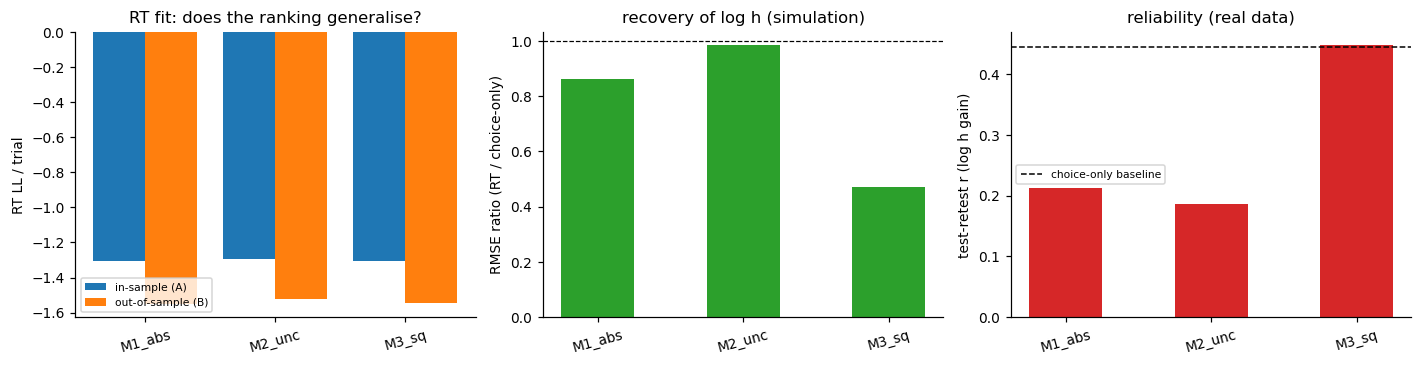

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))

# (1) RT fit: in-sample vs out-of-sample
x = np.arange(len(RT_MODELS))
ax[0].bar(x - .2, EV["RT LL in-sample (run A)"], .4, label="in-sample (A)")
ax[0].bar(x + .2, EV["RT pred LL (run B)"], .4, label="out-of-sample (B)")
ax[0].set_xticks(x); ax[0].set_xticklabels(RT_MODELS, rotation=15)
ax[0].set(ylabel="RT LL / trial", title="RT fit: does the ranking generalise?")
ax[0].legend(fontsize=7)

# (2) recovery: RMSE ratio (below 1 = RT helps)
ax[1].bar(x, EV["RMSE ratio (log h gain)"], .5, color="C2")
ax[1].axhline(1, color="k", lw=.8, ls="--")
ax[1].set_xticks(x); ax[1].set_xticklabels(RT_MODELS, rotation=15)
ax[1].set(ylabel="RMSE ratio (RT / choice-only)", title="recovery of log h (simulation)")

# (3) reliability against the baseline
ax[2].bar(x, EV["reliability r (log h gain)"], .5, color="C3")
ax[2].axhline(rel.loc["log_h_gain","baseline"], color="k", lw=1, ls="--",
              label="choice-only baseline")
ax[2].set_xticks(x); ax[2].set_xticklabels(RT_MODELS, rotation=15)
ax[2].set(ylabel="test-retest r (log h gain)", title="reliability (real data)")
ax[2].legend(fontsize=7)

plt.tight_layout(); savefig_show("fig8_evidence")

## 8. Recommendation, limitations and next steps

### 8.1 Which value$\to$RT mapping do we recommend?

**Recommendation: M3 (quadratic conflict, $\mu = a - b\,\Delta V^2$).**

*The RT data alone cannot choose.* On the common predictive quantity the brief requires --
the RT predictive log-likelihood on run B -- the three mappings are indistinguishable:
M2 $-1.524$, M3 $-1.544$, M1 $-1.548$ nats/trial, with every pairwise Wilcoxon
$p > 0.15$ (M1 vs M2 $p=0.84$, M2 vs M3 $p=0.41$, M1 vs M3 $p=0.16$). The ordering is
also unstable across conditions -- M2 is nominally best on reward trials, M1 on loss
trials -- and the in-sample ranking does **not** generalise: on run A, M2 beat M1
($p=0.005$) and M3 ($p=0.014$), yet that advantage disappears entirely out of sample.
Selecting on the RT likelihood alone would therefore be selecting on noise.

*The tie is broken on identifiability and reliability,* the two criteria the brief also asks
us to weigh, and there M3 is unambiguously ahead:

| Criterion (on $\log h$) | M1 | M2 | **M3** | baseline |
|---|---|---|---|---|
| Recovery $r$ (gain) | 0.925 | 0.900 | **0.977** | 0.89--0.90 |
| RMSE ratio vs choice-only (gain / loss) | 0.86 / 0.72 | 0.98 / 0.88 | **0.47 / 0.49** | 1 |
| Test--retest $r$ (gain) | 0.212 | 0.187 | **0.447** | 0.444 |
| Test--retest $r$ (loss) | 0.118 | 0.099 | **0.304** | 0.124 |
| $\Delta$ choice LL vs baseline | $-0.010$ | $-0.013$* | $-0.010$ | -- |

(*M2's loss of choice predictive LL is the largest and comes closest to significance,
$p=0.053$; none of the three reaches $p<0.05$.)

M3 halves the simulated recovery error of both discount rates relative to a choice-only
fit, and it is the **only** RT model that does not damage the real-data test--retest
reliability of the constructs we care about: it leaves $\log h_{gain}$ untouched
($\Delta r = +0.003$, bootstrap CI $[-0.21, +0.23]$) and more than doubles $\log h_{loss}$
($\Delta r = +0.180$, CI $[-0.04, +0.40]$), whereas M1 and M2 roughly halve the reliability
of $\log h_{gain}$ ($\Delta r = -0.23$ and $-0.26$; M2's CI $[-0.53, -0.01]$ excludes zero).

*Why M3 behaves better is intelligible, not accidental.* Its predictor $\Delta V^2$ places
essentially all of its leverage on near-indifference trials. Those are exactly the trials
whose $\Delta V$ is most tightly constrained by the choice data, so the RT term reinforces
the part of the value function the choices already determine well. M1's $|\Delta V|$ and
M2's $|2P-1|$ instead spread their leverage over easy trials, where $\Delta V$ is poorly
constrained (any large value difference predicts the same choice), so the RT term pulls
$h$ around in order to fit RT variance that carries no choice information.

### 8.2 Was modelling RT worthwhile?

**For predicting choices: no.** No RT model improves held-out choice prediction. All three
are slightly *worse* than the choice-only baseline on every choice metric -- choice
predictive LL $-0.630 \to -0.640/-0.643/-0.640$, balanced accuracy $0.699 \to 0.689$--$0.692$,
AUC $0.756 \to 0.750$--$0.754$ -- though none of the three losses reaches significance (M2 is
the largest, $p=0.053$). The joint
likelihood must spend its parameters on RT as well, and in this data set that trade is not
repaid in choice prediction.

**For estimating the constructs: yes, but only under M3, and with a caveat.** M3 buys a
large improvement in simulated recovery (RMSE roughly halved for both discount rates,
paired $p < 10^{-4}$) and the only real-data reliability gain we observed
($\log h_{loss}$: $0.124 \to 0.304$), at a cost in choice prediction of $0.010$ nats/trial
that is not statistically distinguishable from zero ($p=0.11$). If the goal is predicting
choices, drop RT. If the goal is a stable, better-identified estimate of the discount rates
-- the usual reason for fitting these models -- M3 is worth its cost.

### 8.3 What the analyses could and could not establish

*Could:* that all four choice parameters are well recovered ($r \ge 0.89$ everywhere,
$\ge 0.96$ under M3); that non-decision time $\tau$ is **not** identifiable
($r = 0.19$--$0.29$, upward bias $\approx +0.05$ s) because it trades off against the RT
intercept $a$ (correlation between their recovery errors $= -0.64$ under M1 and M3) -- the
two enter the predicted RT almost interchangeably at this sample size; that the reflection
effect is real and large in this sample ($h_{gain} \approx 3.2$ vs $h_{loss} \approx 0.35$
model-free, reproduced by the fits); and that the RT-informed vs choice-only question has
opposite answers depending on which mapping is used, which is itself the main result.

*Could not:* establish that any one mapping is the true one. The decisive reason is that the
empirical difficulty effect is very weak -- the within-participant slope of $\log$RT on
$|\Delta V|$ is $-0.027$, and the raw pooled slope is $+0.063$, i.e. even the *sign* is
unstable once participant-level RT offsets are handled differently. The recovery simulation
draws $b$ from ranges that imply a much stronger effect, which is precisely why the
simulation says "RT helps a lot" while the real data say "RT helps a little, or hurts". The
simulation therefore characterises what RT *could* contribute in a task where difficulty
genuinely modulates RT; it does not license the claim that it does so here. Median fitted
$b$ is only weakly positive ($+0.11$ / $+0.30$ / $+0.15$ for M1/M2/M3) and is negative in
20/49, 11/49 and 16/49 participants respectively.

### 8.4 Limitations

1. **Weak RT signal.** As above: with a near-null difficulty effect the RT likelihood mostly
   contributes noise, and the comparison between mappings has little power. A task with
   wider difficulty variation (or more trials per participant) would be a fairer test of the
   same question.
2. **Descriptive, not mechanistic, RT model.** A shifted log-normal with a value-driven
   location is a regression on RT, not a sequential-sampling process. It cannot separate
   drift from boundary, so a speed--accuracy shift and a change in valuation are confounded
   in $b$. This is also the most likely reason RT can *degrade* the choice parameters: in a
   real DDM the boundary would absorb the overall speed level instead of pushing it into $h$.
3. **M2 is the least numerically stable model.** Its likelihood has the flattest optimum
   (the optimiser reports convergence for 96% of run A fits, against 100% for the other
   models), and its estimates shift slightly across BLAS/SciPy versions while M1, M3 and
   the baseline reproduce bit-identically. The shifts are small (e.g.\ choice
   $\Delta$LL $-0.0140$ vs $-0.0127$), but they are large enough to move a borderline
   $p$-value across $0.05$, which is a further reason not to rest a conclusion on M2.
4. **$\tau$ is unidentified and its parameterisation is data-dependent**
   ($\tau = \sigma(\tau_{raw})\cdot 0.99\min(\mathrm{RT})$), so it is anchored to a single
   extreme observation per participant--run. Run B RTs below run A's $\tau$ (0.25--0.28% of
   trials) are floored at $\mathrm{LL} = -20$; that floor contributes on the order of
   0.05 nats/trial, which is the same order as the differences between the RT models, so the
   nominal M2 > M3 > M1 ordering should not be read as robust.
5. **No pooling.** Estimation is per-participant MAP with weakly informative priors.
   19 of 49 participants are flagged as poorly identified by the likelihood-curvature
   diagnostic (14 flat in $\log h_{gain}$, 14 in $\log h_{loss}$), and the reliability
   estimates are visibly attenuated by them (restricting to the 30 well-identified
   participants raises M1's $\log h_{gain}$ reliability from 0.21 to 0.42). A hierarchical
   model would shrink these instead of leaving them noisy.
6. **Fixed structure.** One $\beta$ across reward and loss conditions although choices track
   value more sharply for losses; $\Delta V$ normalised by mean magnitude, which removes
   magnitude effects by construction; parameters assumed constant within a run (no learning,
   drift or fatigue); trial order ignored, although RT autocorrelation is well documented.
7. **Recovery design.** Each replicate reuses one real participant's design and a single
   parameter draw; the ranges in `GEN`/`GEN_B` are taken from the run A fits, so recovery
   quality is conditional on that choice, and $b$'s RMSE is not comparable across models
   (its predictors live on different scales).

### 8.5 Next steps

1. **Fit a proper sequential-sampling model** (DDM or LBA) in which $\Delta V$ drives drift
   and a separate boundary carries speed--accuracy, then re-ask the same question. That is
   the direct test of whether RT hurts the discount rates because the signal is genuinely
   absent or because our functional form is wrong.
2. **Hierarchical estimation** with partial pooling on
   $(\log h_{gain}, \log h_{loss}, \log\beta, b)$, which should stabilise the 19
   poorly-identified participants and give the reliability comparison enough power to
   separate $\Delta r = 0.18$ from zero.


In [31]:
# ---------- persist the figures/numbers cited in the report ----------
RESDIR = Path("results"); RESDIR.mkdir(exist_ok=True)
EVAL.to_csv(RESDIR / "runB_eval_per_participant.csv", index=False)
RELI.to_csv(RESDIR / "reliability.csv", index=False)
REC_FULL.to_csv(RESDIR / "recovery_with_rt.csv")
CMP.to_csv(RESDIR / "recovery_rt_vs_choiceonly.csv")
RT_HELPS_CHOICE.to_csv(RESDIR / "does_rt_help_choice.csv", index=False)
RT_HELPS_REC.to_csv(RESDIR / "does_rt_help_recovery.csv", index=False)
TAB_RT.to_csv(RESDIR / "rt_predictive_ll_runB.csv")
EV.to_csv(RESDIR / "evidence_summary.csv")
for m in ALL_MODELS:
    PARS_A[m].to_csv(RESDIR / f"params_runA_{m}.csv")
    PARS_B[m].to_csv(RESDIR / f"params_runB_{m}.csv")

print("figures written to figures/:", sorted(f.name for f in FIGDIR.glob("*.pdf")))
print("tables  written to results/:", sorted(f.name for f in RESDIR.glob("*.csv")))
print("\nRECOMMENDATION: M3_sq (quadratic conflict).")
print("  - the three RT models are indistinguishable on the RT predictive LL (all pairwise")
print("    p >= 0.16), so the RT data alone cannot select a mapping;")
print("  - M3 is the only mapping that preserves choice-parameter reliability, and it halves")
print("    the simulated recovery error of both discount rates;")
print("  - modelling RT does NOT improve held-out CHOICE prediction under any mapping.")


figures written to figures/: ['fig1_data.pdf', 'fig2_insample.pdf', 'fig3_recovery.pdf', 'fig4_recovery_matrix.pdf', 'fig5_reliability.pdf', 'fig6_prediction.pdf', 'fig7_rt_choice.pdf', 'fig8_evidence.pdf']
tables  written to results/: ['does_rt_help_choice.csv', 'does_rt_help_recovery.csv', 'evidence_summary.csv', 'params_runA_M1_abs.csv', 'params_runA_M2_unc.csv', 'params_runA_M3_sq.csv', 'params_runA_baseline.csv', 'params_runB_M1_abs.csv', 'params_runB_M2_unc.csv', 'params_runB_M3_sq.csv', 'params_runB_baseline.csv', 'recovery_rt_vs_choiceonly.csv', 'recovery_with_rt.csv', 'reliability.csv', 'rt_predictive_ll_runB.csv', 'runB_eval_per_participant.csv']

RECOMMENDATION: M3_sq (quadratic conflict).
  - the three RT models are indistinguishable on the RT predictive LL (all pairwise
    p >= 0.16), so the RT data alone cannot select a mapping;
  - M3 is the only mapping that preserves choice-parameter reliability, and it halves
    the simulated recovery error of both discount rates;
 